<a href="https://colab.research.google.com/github/markfortune/luas_dev/blob/main/New_Luas_Update_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Some quick installs for Colab (JAX and pymc should already be installed)

In [ ]:
!mkdir downloads
%cd downloads

#Install current development version of luas
!git clone https://github.com/markfortune/luas_dev.git
%cd luas_dev
!pip install .
%cd ..

# Install latest commit of tinygp (contains necessary bug fixes)
!git clone https://github.com/dfm/tinygp.git
%cd tinygp
!pip install .
%cd ..

# Install jaxoplanet for light curve generation
!pip install jaxoplanet

# Useful for visualising inference later in tutorial
!pip install corner
%cd ..

# New luas update (Emission Spectroscopy Example)

This notebook provides to tutorial to new ``luas`` kernels in the context of fitting multi-wavelength emission light curves. We generate our emission light curves using a convenience function in `luas` which uses `jaxoplanet` for its light curve generation. We show how to build various kernel functions and include priors on some parameters. Finally, we demonstrate how to use ``PyMC`` to fit noise contaminated light curves and recover an input emission spectrum.

In [1]:
import os
# This can make some tinygp functions run faster
os.environ["XLA_FLAGS"] = "--xla_backend_extra_options=xla_cpu_small_while_loop_byte_threshold=1000000"

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import logging
import pandas as pd
import luas
import pymc as pm
import numpy as np
from copy import deepcopy

# Useful to set when looking at retrieved values for many parameters
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# This helps give more information on what PyMC is doing during inference
logging.getLogger().setLevel(logging.INFO)

# Running this at the start of the runtime ensures jax uses 64-bit floating point numbers
# as jax uses 32-bit by default
jax.config.update("jax_enable_x64", True)

# This will list available CPUs/GPUs JAX is picking up
print("Available devices:", jax.devices())

Available devices: [CpuDevice(id=0)]


First we will use [jaxoplanet](https://github.com/exoplanet-dev/jaxoplanet) which has its own documentation and tutorials [here](https://jax.exoplanet.codes/en/latest/). For simplicity here, we just use the luas convenience function ``eclipse_2D`` from ``luas.exoplanet``, which is optimised for multi-wavelength fitting (i.e. it generates a single transit light curve and scales it by $f_p/f_*$ and linear baseline parameters).

If swapping in another ``JAX`` mean function in its place, it needs to be of the form ``f(p, X, *mf_args, **mf_kwargs)`` where p is a ``dict``/``PyTree`` and ``X`` is a ``tuple`` of regression vectors in each dimension, which is a standardised form needed by many input ``luas`` functions. It should return an array in the same shape as the input data.

Note, parameters which will be shared between light curves are assumed to be size-1 arrays here, this will make it easier to implement multi-light curve fitting with PyMC later.

Shape of model: (32, 1024)


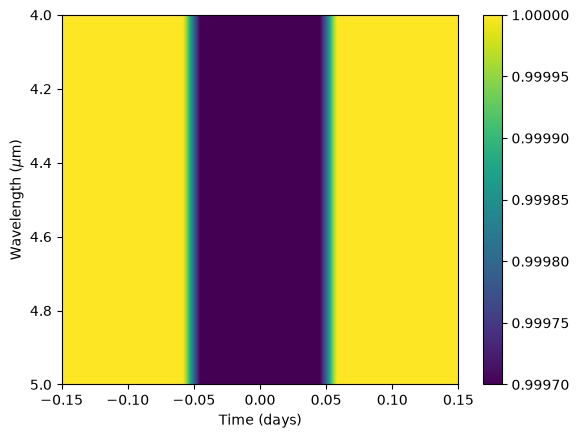

In [2]:
from luas.exoplanet import eclipse_2D

# Let's define a wavelength range of our data, this isn't actually used by our mean function
# but we will use it for defining correlation in wavelength later
N_l = 32 # Feel free to vary the number of light curves, even >100 light curves can perform quite efficiently
x_l = np.linspace(4., 5., N_l)

# Generate evenly spaced time points (in units of days)
N_t = 1024
x_t = jnp.linspace(-0.15, 0.15, N_t)

mfp = {
    "T0":0.*np.ones(1),            # Central transit time
    "P":3.*np.ones(1),             # Period (days)
    "a":8.*np.ones(1),             # Semi-major axis to stellar ratio aka a/R*
    "rho":0.1*np.ones(1),          # Planet to star radius ratio (aka Rp/R*)
    "fp_fs":300e-6*np.ones(N_l),   # Eclipse depth (aka fp/f*)
    "b":0.5*np.ones(1),            # Impact parameter
    "Foot":1.*np.ones(N_l),        # Baseline flux out of transit
    "Tgrad":0.*np.ones(N_l),       # Gradient in baseline flux (days^-1)
}

# The mean function must start with these two arguments:
#   p: a PyTree of parameters
#   X: the regression vectors as a tuple of arrays in each dimension as below
X = (x_l, x_t)

# Our mean function must return an array in the same shape as our data Y
eclipse_model_2D = eclipse_2D(mfp, X)

print(f"Shape of model: {eclipse_model_2D.shape}")

# Visualise the transit light curves
plt.imshow(eclipse_model_2D, aspect = 'auto', extent = [x_t[0], x_t[-1], x_l[-1], x_l[0]])
plt.xlabel("Time (days)")
plt.ylabel(r"Wavelength ($\mu$m)")
plt.colorbar()
plt.show()

We can include priors on some of these parameters if we need to, such as the planetary period $P$ or various other orbital parameters. Once again, the form of this function should be``logPrior(p, X, *logPrior_args, **logPrior_kwargs)``, and in this case should return a scalar value.

In [3]:
# Create a simple dict storing prior means and standard deviations on each parameter
p_prior = {
    "P":(3., 1e-7),    # Period (days)
    "rho":(0.1, 1e-4),    # Planet to star radius ratio (aka Rp/R*)
    "a":(8., 0.1),      # Semi-major axis to stellar ratio aka a/R*
    "b":(0.5, 0.01),    # Impact parameter
}

# The logPrior function also starts with the same two arguments as the mean function
#   p: a PyTree of parameters (including mean function parameters and hyperparameters)
#   X: the regression vectors as a tuple of arrays in each dimension

# It should return as the logPrior value as a float
def logPrior(p, X):
    logPrior = -0.5*((p["P"][0] - p_prior["P"][0])/p_prior["P"][1])**2
    logPrior += -0.5*((p["rho"][0] - p_prior["rho"][0])/p_prior["rho"][1])**2
    logPrior += -0.5*((p["a"][0] - p_prior["a"][0])/p_prior["a"][1])**2
    logPrior += -0.5*((p["b"][0] - p_prior["b"][0])/p_prior["b"][1])**2

    return logPrior

print("Log prior at starting values:", logPrior(mfp, X))

Log prior at starting values: -0.0


Now that we have our mean function created, it's time to start building a 2D kernel function. For this example, suppose we have white noise which varies in amplitude over different wavelengths but with a constant amplitude in time. We also have some measurement covariance which could arise from some detector effect, i.e. each spectrum has some correlated noise draw added to it which is independent for each integration, such as due to 1/f readout noise, which we model here simply as an exponential kernel in wavelength.

$$
\begin{equation}
k(\lambda, \lambda', t, t') = \left[\sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right)\right]\delta_{t t'}\nonumber
\end{equation}
$$

This kernel can be written as a single wavelength kernel function times a single time kernel function:
$$
\begin{aligned}
    s_\lambda(\lambda, \lambda') &= \sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right)\\
    s_t(t, t') &= \delta_{t t'}
\end{aligned}
$$

In this scenario, we can describe the full covariance matrix created as a single Kronecker product of a wavelength covariance matrix and a time covariance matrix:
$$
\begin{aligned}
    (\Sigma_\lambda)_{ij} &= s_\lambda(\lambda_i, \lambda_j)\\
    (\Sigma_t)_{ij} &= s_t(t_i, t_j)\\
    \mathbf{K} &= \Sigma_\lambda \otimes \Sigma_t
\end{aligned}
$$
This mathematical structure will be exploited by the ``SingleKronTermKernel`` GP optimisation as implemented by ``luas``, originally from Saatchi (2011).

Let's start with building these kernels individually. ``luas`` has a simple kernel building interface where kernels can be added together and multiplied easily


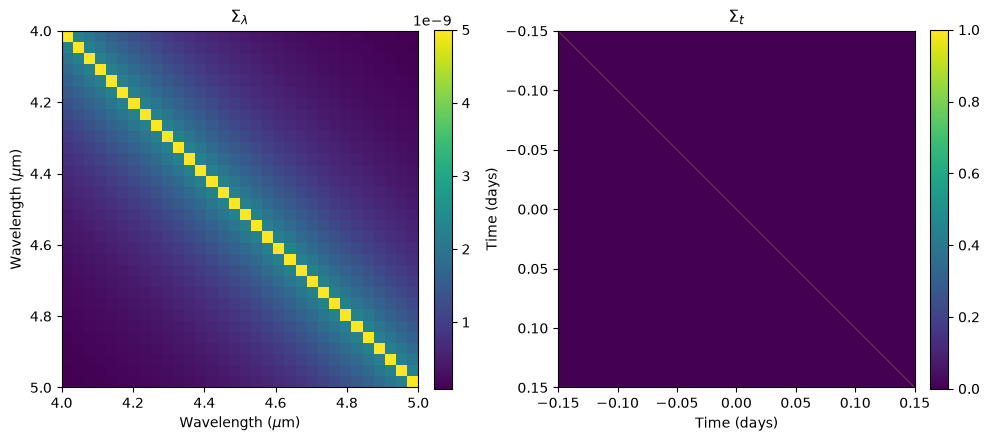

In [4]:
p = {
    "log_sigma":np.log(50e-6)*np.ones(N_l),
    "sigma_t":np.linspace(0.5, 2., N_t),

    "log_h_readout":np.log(50e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),
}

# We use the Noise kernel to describe white noise, so it goes to zero when calculating the GP mean
# Currently takes the standard deviation of the white noise (might change to variance in final released code)
s_l = luas.kernels.Noise(jnp.exp(p["log_sigma"]))

# Add our readout noise term, note we can just multiply scalars by kernels too
s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.Exp(jnp.exp(p["log_l_readout"][0]))

# If you would like to build the covariance matrix, give it the regression vectors x and x' to build it
# matching the convention in tinygp
Sigma_l = s_l(x_l, x_l)

# The KroneckerDelta kernel is the same as the Noise kernel but it won't go to zero for the GP mean calculation
# It should be used if modelling a kernel term which is uncorrelated in one dimenion,
# but is being multiplied by any kernel terms which are correlated in another dimension
s_t = luas.kernels.KroneckerDelta(1.)
Sigma_t = s_t(x_t, x_t)

# You can also give a vector of standard deviation over time if desired,
# Remember that these values get multiplied by the wavelength covariance matrix
# s_t = luas.kernels.KroneckerDelta(p["sigma_t"])
# Sigma_t = s_t(x_t, x_t)

# Plot these covariance matrices
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].set_title(r"$\Sigma_\lambda$")
im0 = ax[0].imshow(Sigma_l, extent = [x_l[0], x_l[-1], x_l[-1], x_l[0]])
ax[0].set_ylabel(r"Wavelength ($\mu$m)")
ax[0].set_xlabel(r"Wavelength ($\mu$m)")
plt.colorbar(im0, ax = ax[0], fraction=0.046, pad=0.04)
ax[0]

ax[1].set_title(r"$\Sigma_t$")
im1 = ax[1].imshow(Sigma_t, extent = [x_t[0], x_t[-1], x_t[-1], x_t[0]])
ax[1].set_ylabel("Time (days)")
ax[1].set_xlabel("Time (days)")
plt.colorbar(im1, ax = ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


Now that we see how we can create these individual kernel functions, let's create a 2D kernel function which multiplies these together. We will create our kernel from before within the ``kf(p, X)`` function, as this is the preferred interface for inputting a kernel function to the ``luas.GP`` interface. Here are our kernels to implement:
$$
\begin{aligned}
    s_\lambda(\lambda, \lambda') &= \sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right)\\
    s_t(t, t') &= \delta_{t t'}
\end{aligned}
$$

Using GP optimisation SingleKronTermKernel


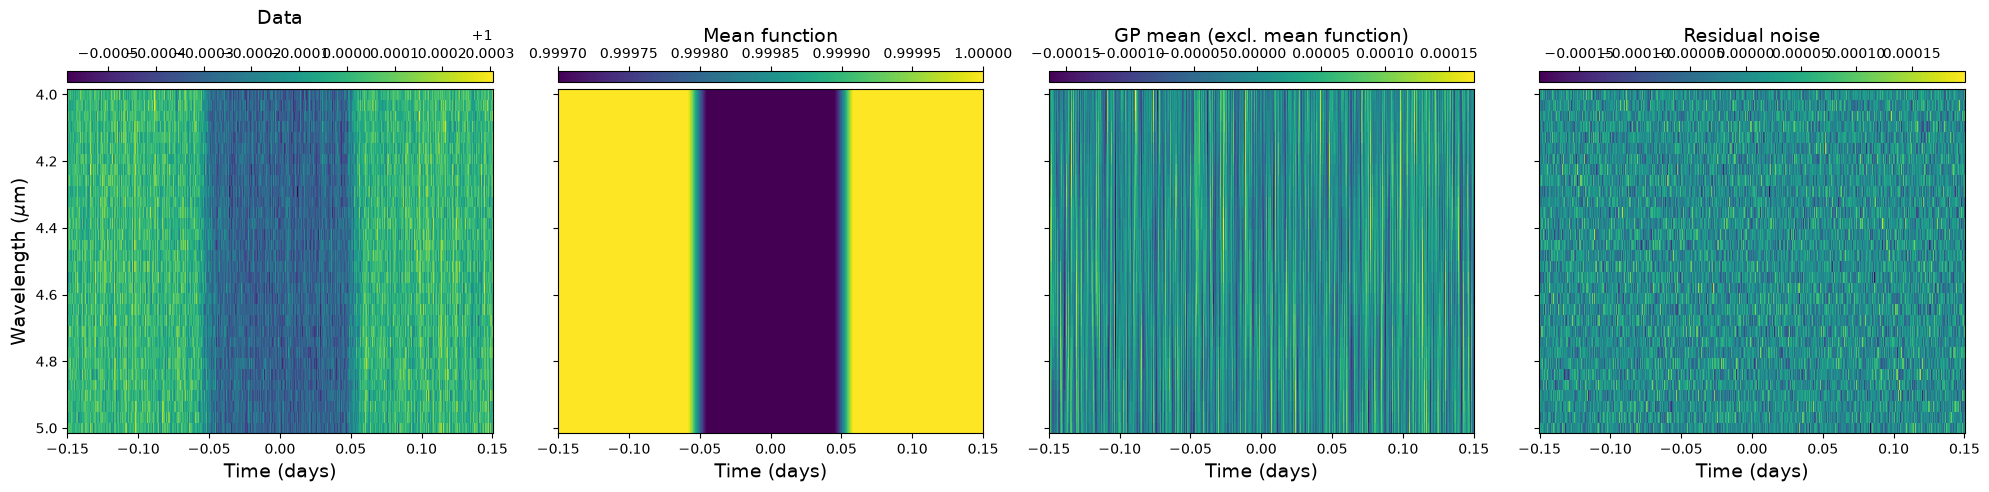

Starting log posterior value: 271786.6886261156


In [5]:
# Input kernel function also starts with the same two arguments
#   p: a PyTree of parameters
#   X: the regression vectors as a tuple of arrays in each dimension
def kf_readout(p, X):
    # We use the Noise kernel to describe actual white noise as it goes to zero when calculating the GP mean
    s_l = luas.kernels.Noise(jnp.exp(p["log_sigma"]))

    # Add our readout noise term
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.Exp(jnp.exp(p["log_l_readout"][0]))

    # Our KroneckerDelta kernel for the time kernel
    # Try seeing what happens if this is changed to luas.kernels.Noise instead,
    # the log-likelihood isn't be affected but the GP mean is
    # It can also take a vector of amplitudes if desired
    s_t = luas.kernels.KroneckerDelta(1.)

    # For multidim kernels we return a tuple containing the wavelength kernel and time kernels
    # The first kernel term will use the regression vector(s) stored in X[0] to build covariance matrices
    # Similarly the second kernel term uses X[1] and so on,
    # we can do 3+ dimensions for the SingleKronTermKernel if desired!
    return (s_l, s_t)

# Feel free to play around with the dataset size to see runtime difference
N_l = 32    # Number of wavelengths
N_t = 1024  # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

# Mean function parameters
p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

# Define our hyperparameters
hp = {
    "log_sigma":np.log(50e-6)*np.ones(N_l),

    "log_h_readout":np.log(50e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),
}
p_init = deepcopy(mfp)
p_init.update(hp)

# Define our GP model, also starting with p, X
gp = luas.GP(p_init, X, mf = eclipse_2D, kf = kf_readout, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# Sample from the GP prior, including both the mean function and a draw from the covariance matrix
# Useful for simulating data and also visualising what the GP model looks like at the starting parameter values
Y = gp.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp_mean, mf_model = gp.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"], return_fit = True)
plt.show()
print("Starting log posterior value:", gp.logP(p_init, Y))

We can see the GP mean contains vertical streaks of correlated noise, characteristic of certain readout noise such as 1/f noise in JWST/NIRCam.

If we look at the white light curve we will see that the readout noise makes it substantially noiser (as it bins down slowly in wavelength)

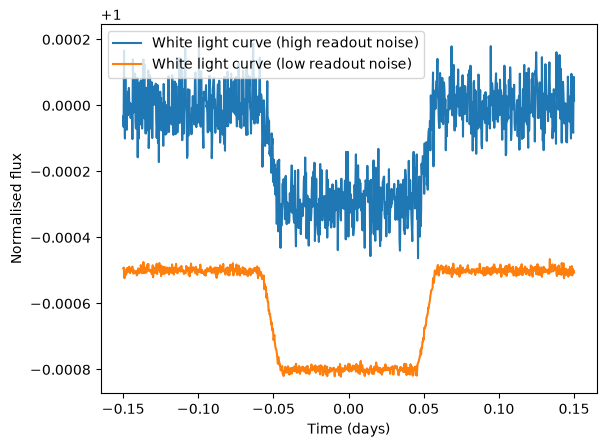

In [6]:
# Copy the original parameters and set high readout noise
p_readout = deepcopy(p_init)
p_readout["log_h_readout"][0] = np.log(100e-6)
Y_readout = gp.sample(p_readout, add_mf = True)
plt.plot(x_t, Y_readout.mean(0), label = "White light curve (high readout noise)")

# Copy the same parameters but lower readout noise to 1e-9
p_clean = deepcopy(p_init)
p_clean["log_h_readout"][0] = np.log(1e-9)

Y_clean = gp.sample(p_clean, add_mf = True)
plt.plot(x_t, Y_clean.mean(0) - 500e-6, label = "White light curve (low readout noise)")

plt.xlabel("Time (days)")
plt.ylabel("Normalised flux")
plt.legend()
plt.show()

We can always visualise all covariance matrices created by the `luas.GP` object using the ``plot_cov_mat`` method, which will create a plot similar to what we made before

Note: For lots of time points pcolormesh can render weirdly which you might see in the time covariance matrix

Warning: Don't run with 10,000s of points in a dimension, you can run out of RAM very quickly!

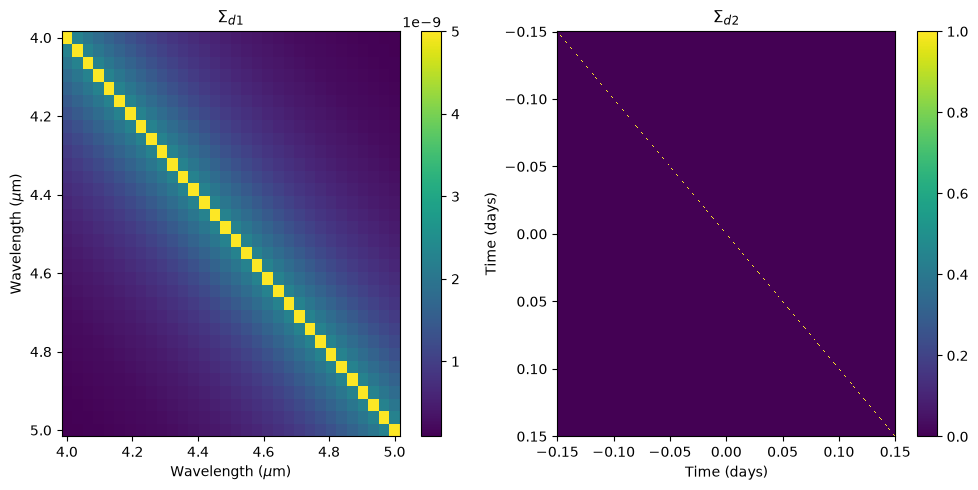

In [7]:
gp.plot_cov_mat(p_init, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"])

Since an exponential kernel plus diagonal noise can be modelled as a quasiseparable kernel, we can swap out our base kernels from ``luas.kernels`` with ``luas.kernels.quasisep`` which can decompose the individual wavelength and time covariance matrices much faster for larger datasets. The ``luas.kernels.quasisep`` submodule is a backend for ``tinygp``, which implements linear time algorithms to decompose quasiseparable kernels, e.g. including the exponential kernel, Matérn-3/2, and Matérn-5/2 kernels exactly. The ``Noise`` and ``KroneckerDelta`` kernels are also valid quasisep kernels and it's good practice to change them to ``luas.kernels.quasisep`` if adding them to other quasisep kernels. Check out the kernels implemented in ``luas.kernels.quasisep`` to see all the kernels that can be used.

We can also see the cost of evaluating the kernel without any 2D optimisation at all, by setting ``use_kernel=luas.GeneralKernel`` to build the full covariance matrix of the data and decompose using a general Cholesky decomposition. Be very careful using this however as it needs to build a $(N_l N_t, N_l N_t)$ covariance matrix, which will very quickly run out of memory after $>10,000$ total points

In [8]:
# Input kernel function also starts with the same two arguments
#   p: a PyTree of parameters
#   X: the regression vectors as a tuple of arrays in each dimension
def kf_readout_quasisep(p, X):

    # We can swap to quasisep kernels in this case which can scale much faster!
    s_l = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.quasisep.Exp(jnp.exp(p["log_l_readout"][0]))

    s_t = luas.kernels.quasisep.KroneckerDelta(1.)

    return (s_l, s_t)

# Feel free to play around with the dataset size to see runtime difference
N_l = 32    # Number of wavelengths
N_t = 100  # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

# Define our hyperparameters
hp = {
    "log_sigma":np.log(50e-6)*np.ones(N_l),

    "log_h_readout":np.log(50e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),
}
p_init.update(hp)

gp_slow = luas.GP(p_init, X, kf = kf_readout, mf = eclipse_2D, logPrior = logPrior)
gp_fast = luas.GP(p_init, X, kf = kf_readout_quasisep, mf = eclipse_2D, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# Sample from the GP prior, including both the mean function and a draw from the covariance matrix
Y = gp_fast.sample(p_init, add_mf = True)


if N_l * N_t < 16000:
    # luas will identify an exact optimisation to use on initialisation,
    # but we are free to specify any valid optimisation or lack thereof we wish
    # To force luas to not use any 2D optimisation and build the full covariance matrix
    # set use_kernel = luas.GeneralKernel, useful for testing purposes
    gp_no_opt = luas.GP(p_init, X, use_kernel = luas.GeneralKernel,
                        kf = kf_readout, mf = eclipse_2D, logPrior = logPrior,
                        )

    logP_no_opt = gp_no_opt.logP(p_init, Y).block_until_ready()
    print(f"Log-posterior without any 2D GP optimisation: {logP_no_opt}")
    print("\nRuntime for log-posterior calculation without any optimisations:")
    %timeit gp_no_opt.logP(p_init, Y).block_until_ready()


logP_slow = gp_slow.logP(p_init, Y).block_until_ready()
logP_fast = gp_fast.logP(p_init, Y).block_until_ready()

print(f"\nLog-posterior with SingleKronTerm and without quasisep kernels: {logP_slow}")
print(f"Log-posterior with SingleKronTerm and quasisep kernels: {logP_fast}")

print(f"\nRuntime for log-likelihood calculation with {gp_slow.opt_name} and base kernels:")
%timeit gp_slow.logP(p_init, Y).block_until_ready()

print(f"\nRuntime for log-likelihood calculation with {gp_fast.opt_name} and quasisep kernels:")
%timeit gp_fast.logP(p_init, Y).block_until_ready()

if N_l * N_t < 16000:
    print("Try increasing the dataset size to see the improved scaling from quasisep kernels")

Using GP optimisation SingleKronTermKernel
Using GP optimisation SingleKronTermKernel
Using GP optimisation GeneralKernel
Log-posterior without any 2D GP optimisation: 26578.15008101653

Runtime for log-posterior calculation without any optimisations:
112 ms ± 5.82 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Log-posterior with SingleKronTerm and without quasisep kernels: 26578.150081016538
Log-posterior with SingleKronTerm and quasisep kernels: 26578.150081016538

Runtime for log-likelihood calculation with SingleKronTermKernel and base kernels:
95.8 μs ± 405 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

Runtime for log-likelihood calculation with SingleKronTermKernel and quasisep kernels:
122 μs ± 311 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Try increasing the dataset size to see the improved scaling from quasisep kernels


Now that we have measurement covariance covered, let's add in some noise which is correlated in time, but constant in wavelength (i.e. common-mode systematics). For correlated noise, let's choose a Matérn-3/2 kernel in time:
$$
\begin{equation}
k(\lambda, \lambda', t, t') = \left[\sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right)\right]\delta_{tt'} + h^2 * \text{Matérn}_{3/2}\left(-\frac{|t - t'|}{l_{t_1}}\right)
\end{equation}
$$

This kernel contains a correlated noise component with height scale $h$ and length scale in time $l_t$. There is also a white noise term with different white noise amplitudes at different wavelengths, and our measurement covariance from earlier.

We can write this kernel as separate wavelength and time kernel functions multiplied together, i.e.
$$
\begin{equation}
k(\lambda, \lambda', t, t') = s_l(\lambda, \lambda')s_t(t, t') + k_l(\lambda, \lambda')k_t(t, t')
\end{equation}
$$
Where we have
$$
\begin{aligned}
    s_l(\lambda, \lambda') &= \sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right) &\hspace{2em} s_t(t, t') &= \delta_{t t'} \\
    k_l(\lambda, \lambda') &= h^2 &\hspace{2em} k_{t_1}(t, t') &= \text{Matérn}_{3/2}\left(-\frac{|t - t'|}{l_{t_1}}\right)
\end{aligned}
$$
Which build two Kronecker products
$$
\begin{equation}
\mathbf{K} = \mathbf{\Sigma}_\lambda \otimes \mathbf{\Sigma}_t + \mathbf{K}_\lambda \otimes \mathbf{K}_t
\end{equation}
$$
WARNING: For numerical stability reasons, it's important that $\mathbf{\Sigma}_l$ and $\mathbf{\Sigma}_t$ are positive definite and well-conditioned (i.e. can be stably inverted), and they must correspond to the first tuple returned by the kernel function, so that ``luas`` knows which ones they are. Matrices which contain positive values added along the diagonal should be well-conditioned as this "regularises" the matrices. Even though the constant kernel in $k_l$ will not build an invertible matrix, and $\mathbf{K}_\lambda$ and $\mathbf{K}_t$ will not be well-conditioned, this is fine because they are added to $\mathbf{\Sigma}_l$ and $\mathbf{\Sigma}_t$ which are invertible.

Using GP optimisation LuasLasrachKernel/MultiLowRankKernel


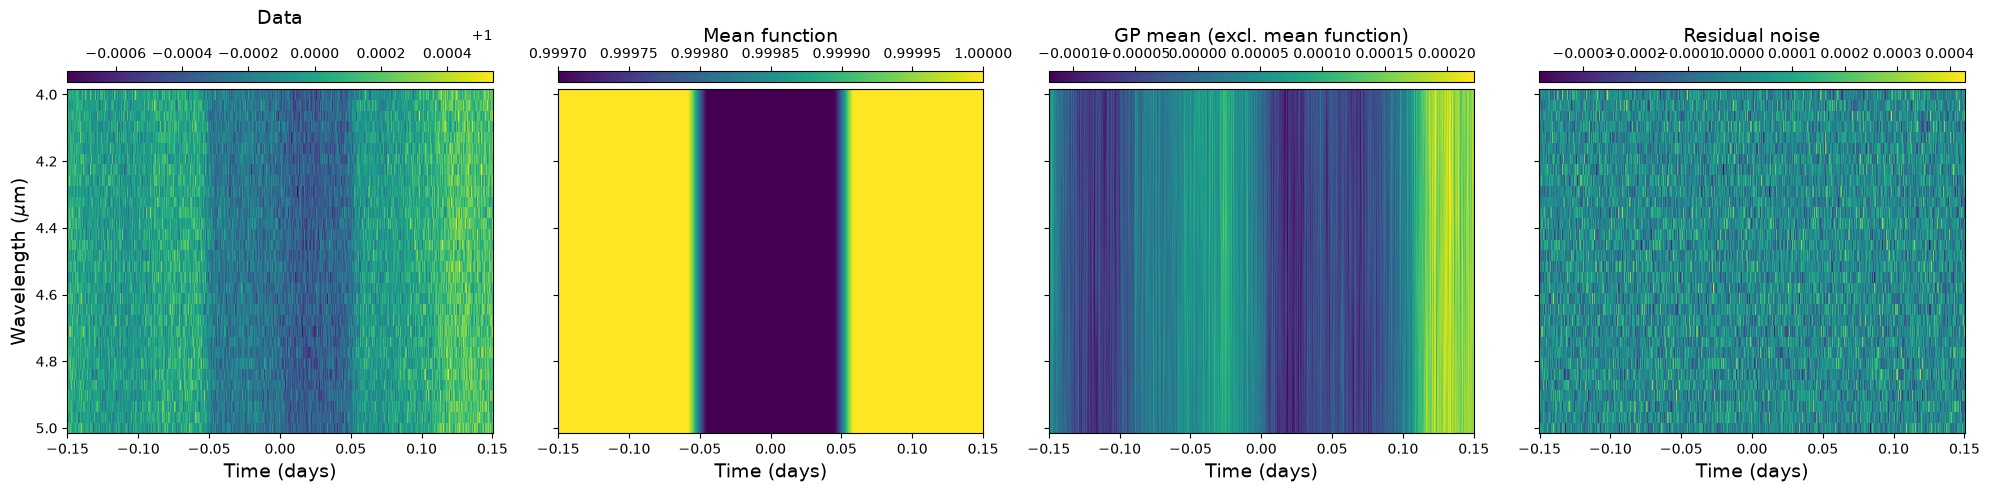


Starting log posterior value: 254093.5283386713


In [9]:
def kf_with_timecorr(p, X):
    # Our kernel with measurement covariance from before
    s_l = luas.kernels.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.Exp(jnp.exp(p["log_l_readout"][0]))
    s_t = luas.kernels.KroneckerDelta()

    # Our kernel describing time-correlated noise which is constant in wavelength
    # Give in terms of constant standard deviation (cov mat will equal this squared)
    k_l = luas.kernels.Constant(jnp.exp(p["log_h"][0]))
    k_t = luas.kernels.Matern32(jnp.exp(p["log_l_t"][0]))

    # Warning: Make sure to include the terms s_l, s_t first as they build invertible covariance matrices
    # We simply include our new Kronecker product as a second returned tuple
    return (s_l, s_t), (k_l, k_t)

# Feel free to play around with the dataset size to see runtime difference
N_l = 32    # Number of wavelengths
N_t = 1024  # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

hp = {
    "log_sigma":np.log(100e-6)*np.ones(N_l),

    "log_h_readout":np.log(30e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),

    "log_h":np.log(80e-6)*np.ones(1),
    "log_l_t":np.log(0.04)*np.ones(1),
}
p_init.update(hp)

gp = luas.GP(p_init, X, mf = eclipse_2D, kf = kf_with_timecorr, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# sample from the GP prior again
Y = gp.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp_mean, mf_model = gp.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"], return_fit = True)
plt.show()
print("\nStarting log posterior value:", gp.logP(p_init, Y))


Our white light curve now has obvious time-correlated noise on top of the increased scatter from readout noise

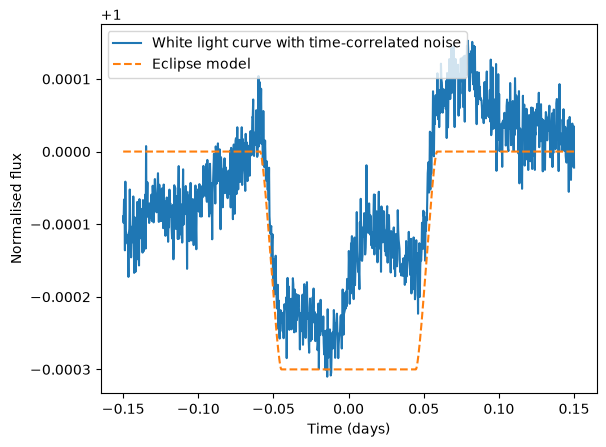

In [10]:
eclipse_model_2D = gp.mf(p_init, X)

# Copy the original parameters and set high readout noise
p_readout = deepcopy(p_init)
Y_readout = gp.sample(p_readout, add_mf = True)
plt.plot(x_t, Y_readout.mean(0), label = "White light curve with time-correlated noise")
plt.plot(x_t, eclipse_model_2D.mean(0), '--', label = "Eclipse model")
plt.xlabel("Time (days)")
plt.ylabel("Normalised flux")
plt.legend()
plt.show()

In the case of a covariance matrix built as a sum of two Kronecker products, we have two different GP optimisations we can use. The first is implemented as the ``LuasKernel``, featured in the original ``luas`` package, which implements the method from Rakitsch et al. (2013). The second is the ``LuasLasrachKernel``* which can utilise a fast GP optimisation in one of the dimensions, such as using quasiseparable kernels. For this to work, all kernel functions in that dimension must be implemented within the same kernel optimisation.

The ideal setup for the ``LuasLasrachKernel`` - assuming we have more time points than wavelengths - is to have $s_\lambda$, $s_t$ and $k_t$ to all build either diagonal matrices (only ``Noise`` and ``KroneckerDelta``) or quasiseparable matrices (created by ``luas.kernels.quasisep``). We also get a big speed-up if $k_\lambda$ is a low-rank matrix from ``luas.kernels.lowrank``:

$$
\begin{equation}
k(\lambda, \lambda', t, t') = s_\mathrm{\lambda; quasi}(\lambda, \lambda')s_\mathrm{t; quasi}(t, t') + k_\mathrm{\lambda; lowrank}(\lambda, \lambda')k_\mathrm{t; quasi}(t, t')
\end{equation}
$$

Our constant kernel is a valid ``luas.kernels.lowrank`` kernel as it builds a covariance matrix with only one non-zero eigenvalue (a rank-1 matrix).

*'luas' is the Irish word for speed (pronounced like Lewis), 'luas lasrach' is the Irish for 'lightning speed' (pronounced like Lewis loss-rock)

Using GP optimisation LuasKernel
Using GP optimisation LuasLasrachKernel/MultiLowRankKernel
Using GP optimisation LuasLasrachKernel/MultiLowRankKernel


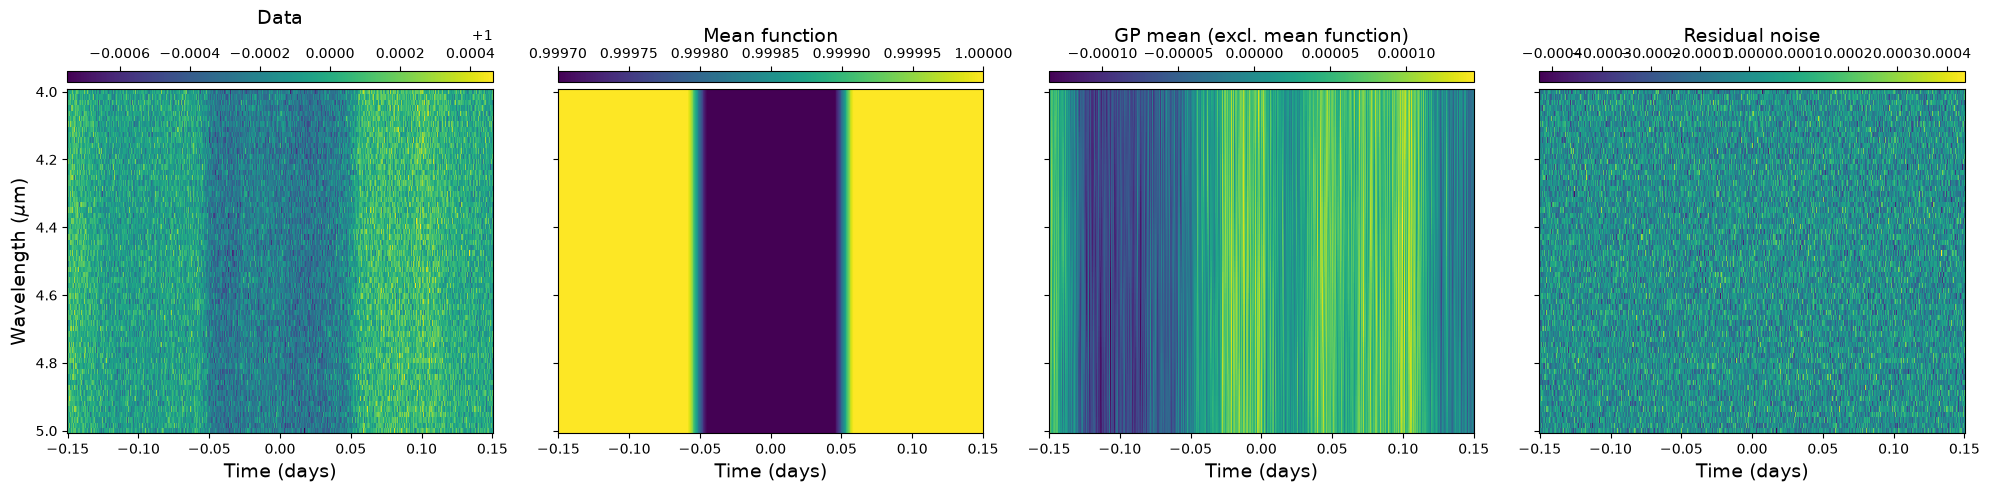

Log-likelihood with LuasKernel: 254262.95685183522
Log-likelihood with LuasLasrachKernel: 254262.9568518363

Runtime for log-likelihood calculation with LuasKernel: 
48.8 ms ± 468 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

Runtime for log-likelihood calculation with LuasLasrachKernel:
378 μs ± 614 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

Runtime for log-likelihood calculation with LuasLasrachKernel without mean function calculation:
166 μs ± 320 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [11]:
# We implement each of these kernel functions below using the luas.kernels module

# Input kernel function also takes a PyTree of parameters and the regression vectors as a tuple of arrays in each dimension
# Order of kernels in each dimension should be in same order as the regression vectors in the tuple X
def kf_slow(p, X):
    # Same kernel as before
    s_l = luas.kernels.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"]) * luas.kernels.Exp(jnp.exp(p["log_l_readout"]))
    s_t = luas.kernels.KroneckerDelta()

    k_l = luas.kernels.Constant(jnp.exp(p["log_h"][0]))
    k_t = luas.kernels.Matern32(jnp.exp(p["log_l_t"][0]))

    return (s_l, s_t), (k_l, k_t)

def kf_fast(p, X):
    # Our kernel with measurement covariance from before
    s_l = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.quasisep.Exp(jnp.exp(p["log_l_readout"][0]))
    s_t = luas.kernels.quasisep.KroneckerDelta()

    # Our kernel describing time-correlated noise which is constant in wavelength
    k_l = luas.kernels.lowrank.Constant(jnp.exp(p["log_h"][0]))
    k_t = luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_t"][0]))

    # Warning: Make sure to include the terms s_l, s_t first as they build invertible covariance matrices which luas will use
    # We simply include our new Kronecker product as a second tuple returned
    return (s_l, s_t), (k_l, k_t)


# Feel free to play around with the dataset size to see runtime difference
N_l = 64    # Number of wavelengths
N_t = 512  # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

hp = {
    "log_sigma":np.log(100e-6)*np.ones(N_l),

    "log_h_readout":np.log(30e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),

    "log_h":np.log(80e-6)*np.ones(1),
    "log_l_t":np.log(0.04)*np.ones(1),
}
p_init.update(hp)

# luas will identify fast, exact optimisations to use on initialisation, but we are free to specify any valid one we wish
# Here we will force it to use LuasKernel, it will otherwise use MultiLowRankKernel which we will explain later
gp_slow = luas.GP(p_init, X, use_kernel = luas.LuasKernel, kf = kf_slow, mf = eclipse_2D, logPrior = logPrior)

# This should default to luas.LuasLasrachKernel if use_kernel is not specified
gp_fast = luas.GP(p_init, X, kf = kf_fast, mf = eclipse_2D, logPrior = logPrior, verbose = True)

# Create a GP object which doesn't generate eclipse light curves for benchmarking purposes
gp_fast_no_mf = luas.GP(p_init, X, kf = kf_fast, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# sample from the GP prior again
Y = gp_fast.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp_mean, mf_model = gp_fast.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"], return_fit = True)
plt.show()

logP_slow = gp_slow.logL(p_init, Y).block_until_ready()
logP_fast = gp_fast.logL(p_init, Y).block_until_ready()

print(f"Log-likelihood with LuasKernel: {logP_slow}\nLog-likelihood with LuasLasrachKernel: {logP_fast}")

print("\nRuntime for log-likelihood calculation with LuasKernel: ")
%timeit gp_slow.logL(p_init, Y).block_until_ready()

print("\nRuntime for log-likelihood calculation with LuasLasrachKernel:")
%timeit gp_fast.logL(p_init, Y).block_until_ready()

print("\nRuntime for log-likelihood calculation with LuasLasrachKernel without mean function calculation:")
gp_fast_no_mf.logL(p_init, Y).block_until_ready()
%timeit gp_fast_no_mf.logL(p_init, Y).block_until_ready()


As you can see, the ``LuasLasrachKernel`` is extremely fast, to the point that the optimised eclipse light curve model becomes a non-negligble part of the runtime (and transit modelling with limb-darkening, etc. can actually become the bottleneck). Part of this insane speed-up is the use of a low-rank kernel in $k_\lambda$, let's swap it to a full-rank kernel like the Matérn-5/2 kernel. We'll give it a short wavelength length scale to simulate systematics that might be close to independent for each wavelength.

$$
\begin{equation}
k(\lambda, \lambda', t, t') = \left[\sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right)\right]\delta_{tt'} + h^2 * \text{Matérn}_{3/2}\left(-\frac{|\lambda - \lambda'|}{l_\lambda}\right)\text{Matérn}_{5/2}\left(-\frac{|t - t'|}{l_{t}}\right)
\end{equation}
$$

Where we have
$$
\begin{aligned}
    s_l(\lambda, \lambda') &= \sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right) &\hspace{2em} s_t(t, t') &= \delta_{t t'} \\
    k_l(\lambda, \lambda') &= h^2 * \text{Matérn}_{5/2}\left(-\frac{|\lambda - \lambda'|}{l_\lambda}\right) &\hspace{2em} k_{t_1}(t, t') &= \text{Matérn}_{3/2}\left(-\frac{|t - t'|}{l_{t}}\right)
\end{aligned}
$$

You may note in this cell that setting $k_\lambda$ to a ``luas.kernels.quasisep`` won't actually result in a speed-up, even though Matérn-5/2 is a valid quasiseparable kernel. This is because an eigendecomposition of the $\mathbf{K}_\lambda$ matrix is required for both ``LuasKernel`` and ``LuasLasrachKernel``, which doesn't have a known optimisation for quasiseparable kernels

Using GP optimisation LuasKernel
Using GP optimisation LuasLasrachKernel
Using GP optimisation LuasLasrachKernel


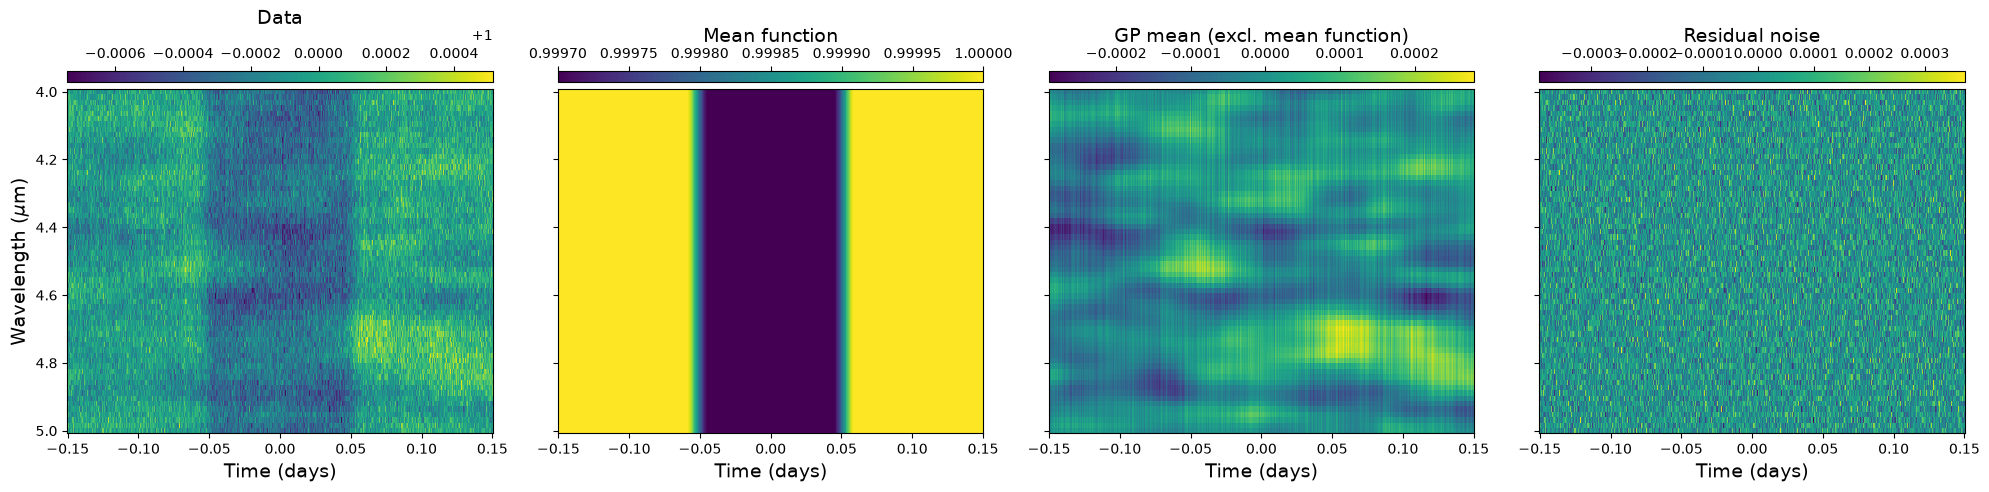

Log-likelihood with LuasKernel: 253726.44311511697
Log-likelihood with LuasLasrachKernel: 253726.44311511697

Runtime for log-likelihood calculation with LuasKernel:
48.9 ms ± 390 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

Runtime for log-likelihood calculation with LuasLasrachKernel:
4.51 ms ± 10.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [12]:
# We implement each of these kernel functions below using the luas.kernels module

# Input kernel function also takes a PyTree of parameters and the regression vectors as a tuple of arrays in each dimension
# Order of kernels in each dimension should be in same order as the regression vectors in the tuple X
def kf_slow(p, X):
    # Same kernel as before
    s_l = luas.kernels.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.Exp(jnp.exp(p["log_l_readout"][0]))
    s_t = luas.kernels.KroneckerDelta()

    k_l = jnp.exp(2*p["log_h"][0]) * luas.kernels.Matern52(jnp.exp(p["log_l_l"][0]))
    k_t = luas.kernels.Matern32(jnp.exp(p["log_l_t"][0]))

    return (s_l, s_t), (k_l, k_t)

def kf_fast(p, X):
    # Our kernel with measurement covariance from before
    s_l = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.quasisep.Exp(jnp.exp(p["log_l_readout"][0]))
    s_t = luas.kernels.quasisep.KroneckerDelta()

    # Our kernel describing time-correlated noise which is constant in wavelength
    k_l = jnp.exp(2*p["log_h"][0]) * luas.kernels.Matern52(jnp.exp(p["log_l_l"][0]))
    k_t = luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_t"][0]))

    # Warning: Make sure to include the terms s_l, s_t first as they build invertible covariance matrices which luas will use
    # We simply include our new Kronecker product as a second tuple returned
    return (s_l, s_t), (k_l, k_t)


# Feel free to play around with the dataset size to see runtime difference
N_l = 64    # Number of wavelengths
N_t = 512  # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

hp = {
    "log_sigma":np.log(100e-6)*np.ones(N_l),

    "log_h_readout":np.log(30e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),

    "log_h":np.log(80e-6)*np.ones(1),
    "log_l_l":np.log(0.05)*np.ones(1),
    "log_l_t":np.log(0.04)*np.ones(1),
}
p_init.update(hp)

# luas will identify fast, exact optimisations to use on initialisation, but we are free to specify any valid one we wish
# Here we will force it to use LuasKernel, it will otherwise use MultiLowRankKernel which we will explain later
gp_slow = luas.GP(p_init, X, use_kernel = luas.LuasKernel, kf = kf_slow, mf = eclipse_2D, logPrior = logPrior)
gp_fast = luas.GP(p_init, X, kf = kf_fast, mf = eclipse_2D, logPrior = logPrior)
gp_fast_no_mf = luas.GP(p_init, X, kf = kf_fast, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# sample from the GP prior again
Y = gp_fast.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp_mean, mf_model = gp_fast.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"], return_fit = True)
plt.show()

logL_slow = gp_slow.logL(p_init, Y).block_until_ready()
logL_fast = gp_fast.logL(p_init, Y).block_until_ready()

print(f"Log-likelihood with LuasKernel: {logL_slow}\nLog-likelihood with LuasLasrachKernel: {logL_fast}")

print("\nRuntime for log-likelihood calculation with LuasKernel:")
%timeit gp_slow.logL(p_init, Y).block_until_ready()

print("\nRuntime for log-likelihood calculation with LuasLasrachKernel:")
%timeit gp_fast.logL(p_init, Y).block_until_ready()


``LuasLasrachKernel`` is still much faster than ``LuasKernel`` here, but not having a low-rank kernel for $k_\lambda$ does significantly slow it down. Their scaling in this case is $\mathcal{O}(N_\lambda^3 + N_t^3 + N_\lambda N_t (N_\lambda N_t))$ for the `LuasKernel` (regardless of quasiseparable kernels) and ~$\mathcal{O}(N_\lambda^2R_{K_\lambda} + R_{K_\lambda} N_t J_{K_t}^2 + N_\lambda N_t J_{\Sigma_\lambda})$ for ``LuasLasrachKernel``, where $J_{\Sigma_\lambda}$ is the quasiseparable rank of $\mathbf{\Sigma}_\lambda$ and similarly for $\mathbf{K}_t$. $R_{K_\lambda}$ is the (eigen) rank of $\mathbf{K}_\lambda$ (i.e. number of non-zero eigenvalues).

We can also scale kernels if they have an amplitude that varies over their own domain, so a wavelength kernel that is larger at some wavelengths than others. We scale this with the `luas.kernels.lowrank.Amplitude` kernel, which takes a vector of amplitudes at each wavelength (be careful not to square it!). We can even scale quasiseparable kernels to vary their amplitude without increasing their quasiseparable rank. Let's do a wavelength-dependent amplitude for the previous model, which could be appropriate for systematics that might be much larger in certain wavelength regions. Our model is:
$$
\begin{equation}
k(\lambda, \lambda', t, t') = \left[\sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right)\right]\delta_{tt'} + \left[h(\lambda)h(\lambda') \text{Matérn}_{5/2}\left(-\frac{|\lambda - \lambda'|}{l_\lambda}\right)\right]\text{Matérn}_{3/2}\left(-\frac{|t - t'|}{l_{t}}\right)\nonumber
\end{equation}
$$

Where we have
$$
\begin{aligned}
    s_\lambda(\lambda, \lambda') &= \sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right) &\hspace{2em} s_t(t, t') &= \delta_{t t'} \\
    k_\lambda(\lambda, \lambda') &= h_\lambda(\lambda)h_\lambda(\lambda') \text{Matérn}_{5/2}\left(-\frac{|\lambda - \lambda'|}{l_\lambda}\right) &\hspace{2em} k_{t}(t, t') &= \text{Matérn}_{3/2}\left(-\frac{|t - t'|}{l_{t}}\right)
\end{aligned}
$$

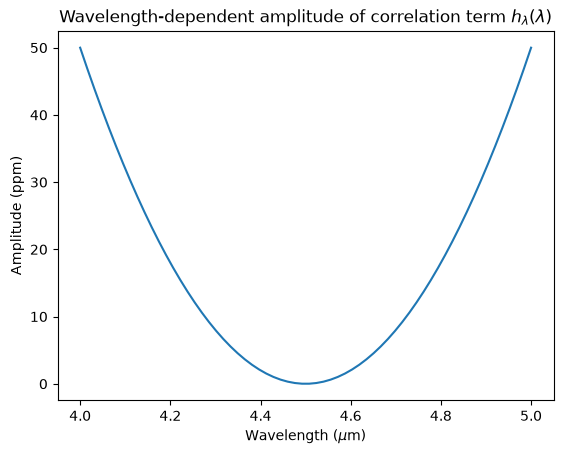

Using GP optimisation LuasLasrachKernel


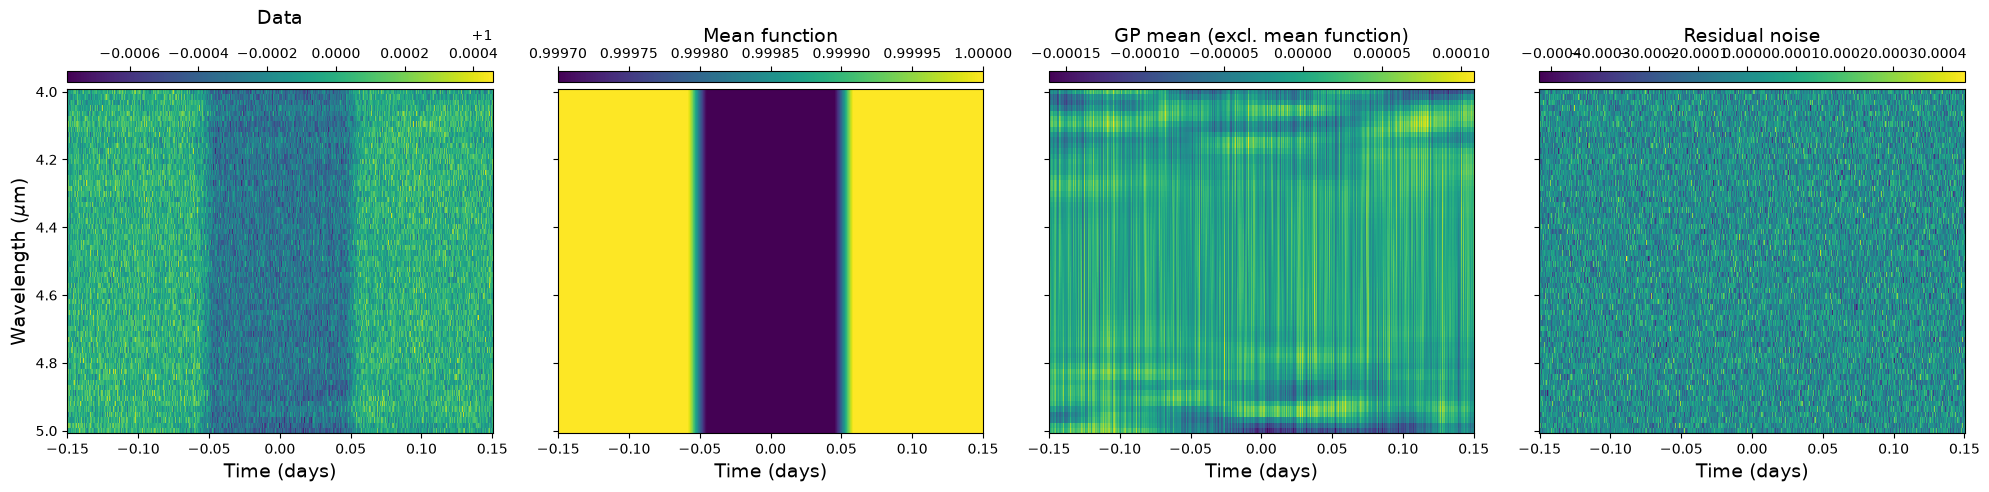

Starting log-posterior value: 508271.02021143783


In [13]:
def kf_scaled2Dkernel(p, X):
    # Our kernel with measurement covariance from before
    s_l = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.quasisep.Exp(jnp.exp(p["log_l_readout"][0]))
    s_t = luas.kernels.quasisep.KroneckerDelta()

    # Our kernel describing time-correlated noise which is constant in wavelength
    k_l = luas.kernels.lowrank.Amplitude(jnp.exp(p["log_h_l"])) * luas.kernels.Matern52(jnp.exp(p["log_l_l"][0]))
    k_t = luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_t"][0]))

    # Warning: Make sure to include the terms s_l, s_t first as they build invertible covariance matrices which luas will use
    # We simply include our new Kronecker product as a second tuple returned
    return (s_l, s_t), (k_l, k_t)


# Feel free to play around with the dataset size to see runtime difference
N_l = 64    # Number of wavelengths
N_t = 1024  # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

h_l_vec = 200e-6 * (X[0] - X[0].mean())**2 * np.ones(N_l)
plt.title(r"Wavelength-dependent amplitude of correlation term $h_\lambda(\lambda)$")
plt.plot(x_l, 1e6 * h_l_vec)
plt.xlabel(r"Wavelength ($\mu$m)")
plt.ylabel("Amplitude (ppm)")
plt.show()

hp = {
    "log_sigma":np.log(100e-6)*np.ones(N_l),

    "log_h_readout":np.log(30e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),

    "log_h_l":np.log(h_l_vec),
    "log_l_l":np.log(0.03)*np.ones(1),
    "log_l_t":np.log(0.04)*np.ones(1),
}
p_init.update(hp)

gp = luas.GP(p_init, X, mf = eclipse_2D, kf = kf_scaled2Dkernel, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# sample from the GP prior again
Y = gp.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp_mean, mf_model = gp.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"], return_fit = True)
plt.show()

logP_val = gp.logP(p_init, Y)
print(f"Starting log-posterior value: {logP_val}")

Since low-rank kernel terms can produce extremely optimised models, they are worth exploring in more detail. We can add arbitrary numbers of kernel terms when they are all low-rank in the same dimension using the ``MultiLowRankKernel`` optimisation. For just a single low-rank term such as the common-mode term from before, this kernel converges exactly to the ``LuasLasrachKernel``, but the ``MultiLowRankKernel`` optimisation extends this to multiple terms and it can also make use of quasiseparable kernels in one of the dimensions. When we combine low-rank kernels with quasiseparable kernels we often get super optimised GP calculations. Mathematically, we are considering kernel functions of this form:
$$
\begin{equation}
    k(\lambda, \lambda', t, t') = s_\lambda(\lambda, \lambda')s_\mathrm{t; quasi}(t, t') + \sum_{i=1}^{N_\alpha}\alpha_i(\lambda) \alpha_i(\lambda') k_\mathrm{t_i; quasi}(t, t') \nonumber
\end{equation}
$$
where $\alpha_i(\lambda)$ can be any function which is used to generate $N_\lambda$-long vectors $\boldsymbol{\alpha}_{\lambda_i}$, and the 'quasi' kernel terms can also be uncorrelated terms such as a Kronecker delta. Note that we don't require these terms to be quasiseparable at all, they could also consist of any `luas.kernels` term, but we can achieve linear scaling in the time dimension if they are.

Alternatively, you can also think of $\mathbf{\alpha}_i = \alpha_i(\lambda)$ as $N_\lambda$-long vectors of free parameters which build the covariance matrix:
$$
\begin{equation}
\mathbf{K} = \mathbf{\Sigma}_{\lambda}  \otimes \mathbf{\Sigma}_{t} + \sum_{i=1}^{N_\alpha} \left(\boldsymbol{\alpha}_{\lambda_i} \boldsymbol{\alpha}_{\lambda_i}^T \otimes \mathbf{K}_{t; i}\right) \nonumber
\end{equation}
$$
For our example, let's take our constant kernel from before, which is equivalent to a constant vector $\mathbf{\alpha}_{\lambda_1} = h * \mathbf{1}$, and let's suppose our tenth light curve also shows significant systematics that we want an extra term to model, this time using a squared-exponential kernel. To keep the optimisation efficient using quasiseparable kernels in time, we can use the ``luas.kernels.quasisep.SquaredExpApprox`` kernel, which produces close approximations to the shape of the true squared exponential kernel (the log-likelihood calculation itself is still exact for the kernel shape it uses, see the next cell). We will also keep our measurement covariance from earlier, resulting in a kernel of:
$$
\begin{aligned}
    s_\lambda(\lambda, \lambda') &= \sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right) &\hspace{2em} s_t(t, t') &= \delta_{t t'} \\
    \mathbf{\alpha}_{\lambda_1} &= h_\mathrm{const} * \mathbf{1} &\hspace{2em} k_{t_1}(t, t') &= \text{Matérn}_{3/2}\left(-\frac{|t - t'|}{l_{t}}\right)\\
    \mathbf{\alpha}_{\lambda_2} &= h_\mathrm{10}\hat{\mathbf{e}}_{10} &\hspace{2em} k_{t_2}(t, t') &= \exp\left(-\frac{|t - t'|^2}{l_{t}^2}\right)
\end{aligned}
$$
We can give our $\mathbf{\alpha}$ vectors to the ``luas.kernels.lowrank.Amplitude`` kernel we used earlier, named in this case since we can think of each low-rank correlation term $\boldsymbol{\alpha}_{\lambda_i} \boldsymbol{\alpha}_{\lambda_i}^T \otimes \mathbf{K}_{t; i}$ as a GP in time with the same shape in all light curves, but scaled by the amplitude $\mathbf{\alpha}_i$ at the $i^\mathrm{th}$ wavelength. Naturally for the basis vector $\hat{\mathbf{e}}_{10}$ the amplitude is zero in all light curves except the 10th light curve.

Using GP optimisation MultiLowRankKernel


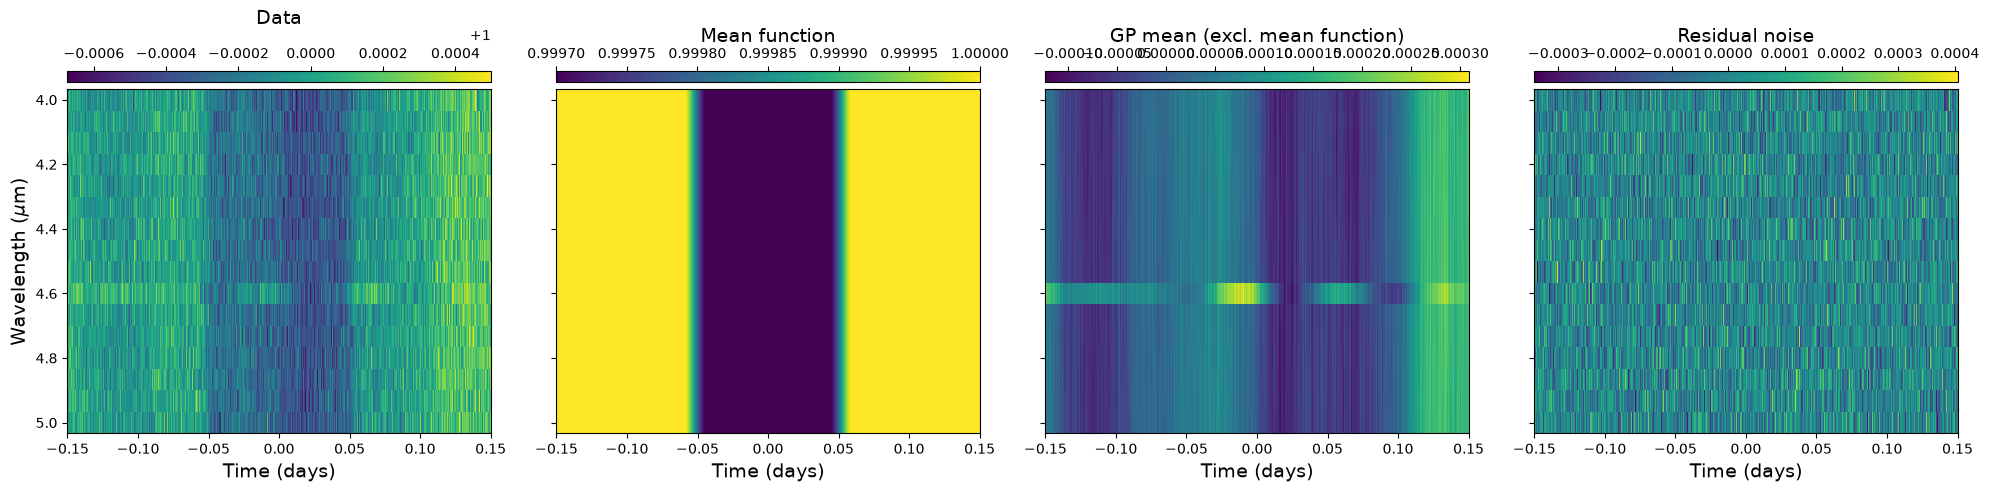


Runtime for log-likelihood calculation with MultiLowRankKernel:
9.43 ms ± 206 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [14]:
def kf_multilowrank(p, X):
    # Our kernel with measurement covariance from before
    s_l = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.quasisep.Exp(jnp.exp(p["log_l_readout"][0]))
    s_t = luas.kernels.quasisep.KroneckerDelta()

    # Our kernel describing time-correlated noise which is constant in wavelength
    alpha_l1 = luas.kernels.lowrank.Constant(jnp.exp(p["log_h_const"][0]))
    k_t1 = luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_t1"][0]))

    # Additional time-correlated systematics in the 10th light curve
    basis_vec = jnp.zeros(X[0].shape[-1])
    basis_vec = jnp.exp(p["log_h10"][0]) * basis_vec.at[9].set(1.)
    alpha_l2 = luas.kernels.lowrank.Amplitude(basis_vec)
    k_t2 = luas.kernels.quasisep.SquaredExpApprox(jnp.exp(p["log_l_t2"][0]))

    # Warning: Make sure to include the terms s_l, s_t first as they build invertible covariance matrices which luas will use
    # We simply include our new Kronecker product as a second tuple returned
    return (s_l, s_t), (alpha_l1, k_t1), (alpha_l2, k_t2)


# Feel free to play around with the dataset size to see runtime difference
N_l = 16    # Number of wavelengths
N_t = 1024  # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

hp = {
    "log_sigma":np.log(100e-6)*np.ones(N_l),

    "log_h_readout":np.log(30e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),

    "log_h_const":np.log(80e-6)*np.ones(1),
    "log_l_t1":np.log(0.04)*np.ones(1),

    "log_h10":np.log(100e-6)*np.ones(1),
    "log_l_t2":np.log(0.02)*np.ones(1),
}
p_init.update(hp)

# luas will automatically identify the MultiLowRankKernel optimisation
gp = luas.GP(p_init, X, mf = eclipse_2D, kf = kf_multilowrank, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# sample from the GP prior again
Y = gp.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp_mean, mf_model = gp.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"], return_fit = True)
plt.show()

print("\nRuntime for log-likelihood calculation with MultiLowRankKernel:")
%timeit gp.logL(p_init, Y).block_until_ready()

Here you can visualise the approximation error in the quasiseparable squared exponential kernel we used in the previous cell. We can play around with the approximation order $J$, which corresponds to the quasiseparable rank of the covariance matrix, where the compute cost scales as ~$\mathcal{O}(NJ^2)$ for matrix decomposition. For this particular approximation, $J$ must be even, and any larger than $J=12$ risks significant numerical stability errors. Beyond the error in the kernel shape, all other calculations are exact, and any approximation order still guarantees a valid kernel function.

We also use this example to show how to build a 1D GP using ``luas``, note that we no longer use a ``tuple`` for the regression vectors, or for what the functions take as input or return.

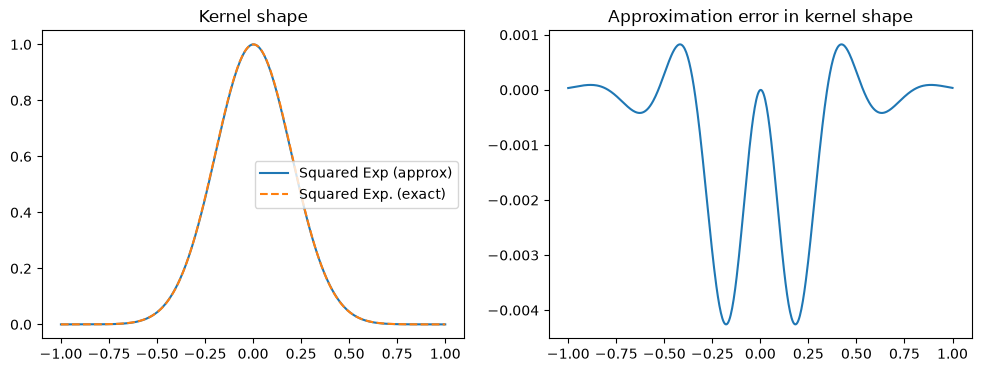

Using GP optimisation General (1D)
Using GP optimisation Quasiseparable (1D)

Exact squared exp fit:


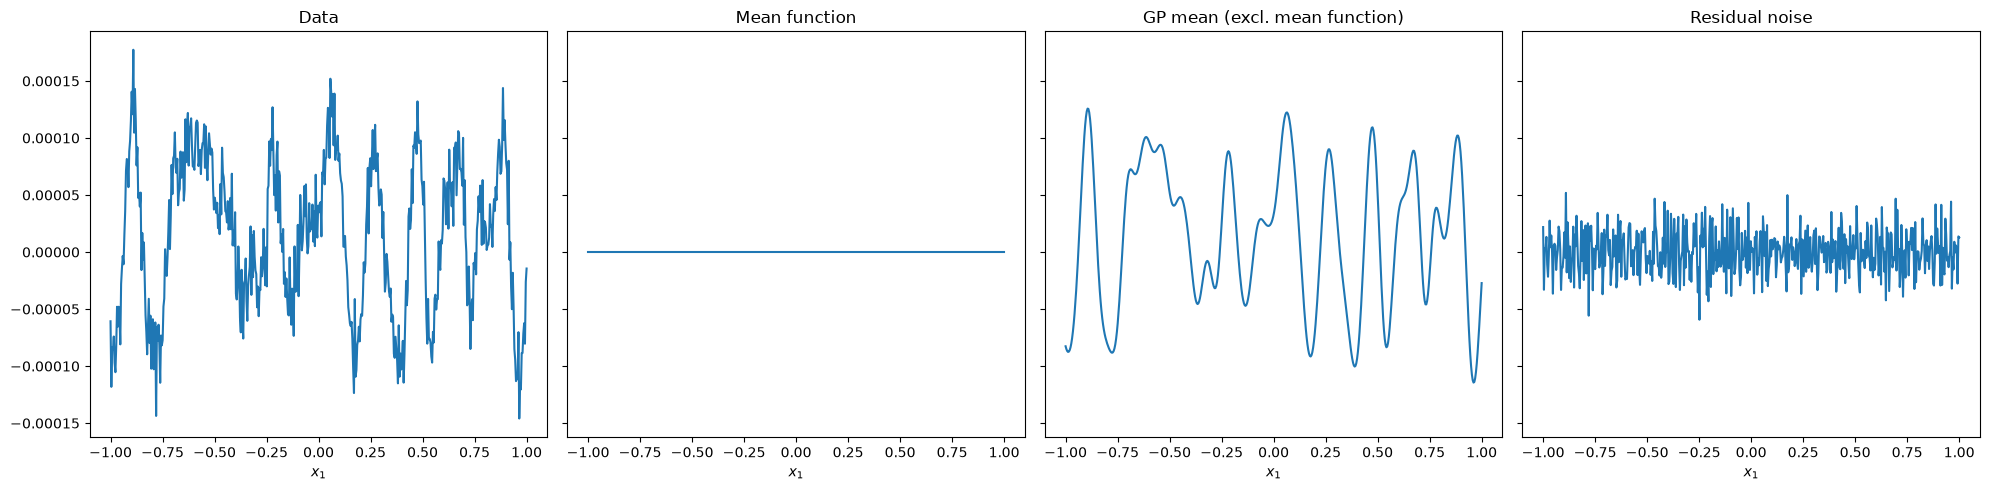


Quasiseparable approx squared exp fit:


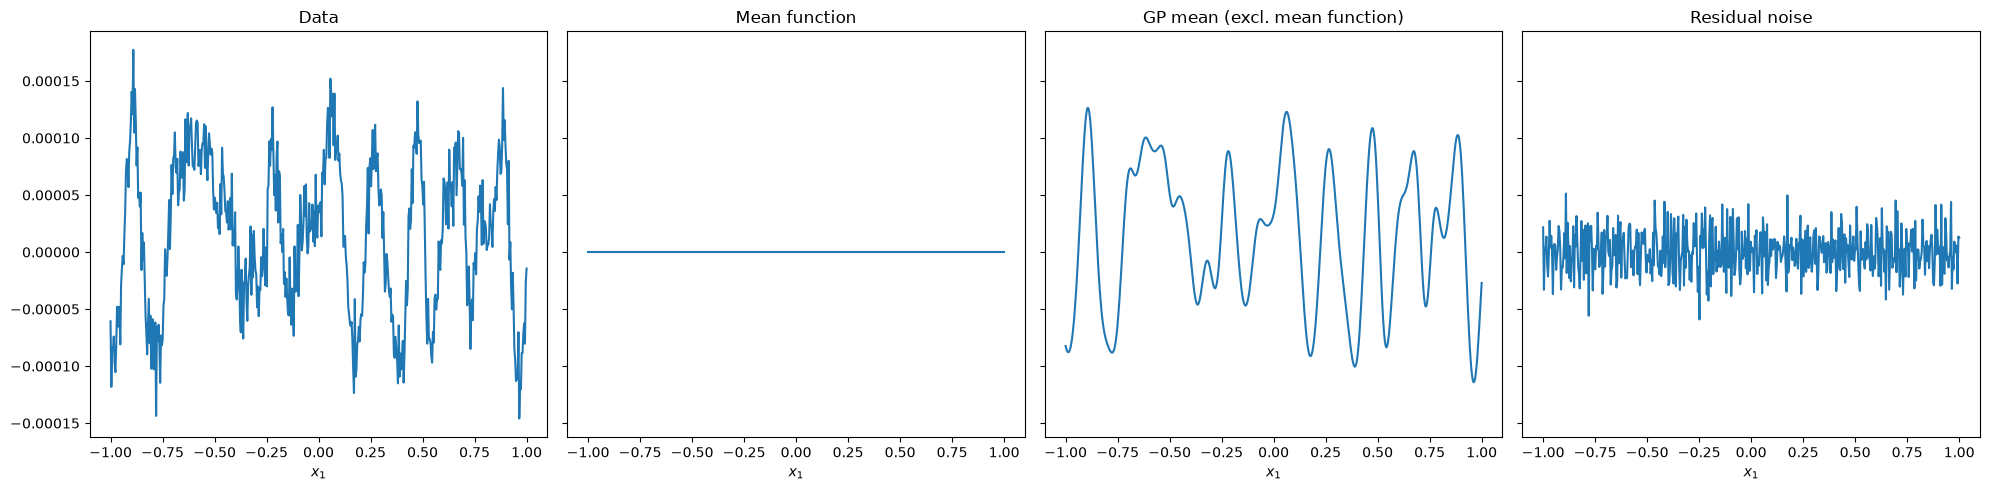

Starting log-posterior value: (exact) 4699.220567915197, (approx) 4698.485391025113


In [15]:
N = 1024  # Number of timepoints
x = jnp.linspace(-1., 1., 512)

# First visualise the approximation error of the quasisep squared exponential kernel
k_squaredexp_exact = luas.kernels.SquaredExp(0.2)

# Defaults to an approximation order of 6, but can be set higher
# avoid order > 12 for numerical stability, use even numbers only
k_squaredexp_app = luas.kernels.quasisep.SquaredExpApprox(0.2, order = 6)
K_eval_exact = k_squaredexp_exact(x, x)
K_eval_app = k_squaredexp_app(x, x)

fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ax[0].set_title("Kernel shape")
ax[0].plot(x, K_eval_app[x.size//2, :], label = "Squared Exp (approx)")
ax[0].plot(x, K_eval_exact[x.size//2, :], label = "Squared Exp. (exact)", linestyle = 'dashed')

ax[1].set_title("Approximation error in kernel shape")
ax[1].plot(x, K_eval_app[x.size//2, :] - K_eval_exact[x.size//2, :], label = "Squared Exp (approx)")
ax[0].legend()
plt.show()

def kf_sqexp(p, x):
    K = luas.kernels.Noise(jnp.exp(p["log_sigma"][0]))
    K += jnp.exp(2*p["log_h"][0]) * luas.kernels.SquaredExp(jnp.exp(p["log_l_t"][0]))

    return K

def kf_quasi_sqexp(p, x):
    K = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"][0]))
    K += jnp.exp(2*p["log_h"][0]) * luas.kernels.quasisep.SquaredExpApprox(jnp.exp(p["log_l_t"][0]))

    return K

p = {
    "log_sigma":np.log(20e-6)*np.ones(1),

    "log_h":np.log(80e-6)*np.ones(1),
    "log_l_t":np.log(0.04)*np.ones(1),
}

gp_sqexp_1D = luas.GP(p, x, kf = kf_sqexp)
gp_quasi_sqexp_1D = luas.GP(p, x, kf = kf_quasi_sqexp)
y_1D = gp_sqexp_1D.sample(p)

print("\nExact squared exp fit:")
gp_mean_exact, mf_model = gp_sqexp_1D.plot(p, y_1D, return_fit = True)
plt.show()

print("\nQuasiseparable approx squared exp fit:")
gp_mean_approx, mf_model = gp_quasi_sqexp_1D.plot(p, y_1D, return_fit = True)
plt.show()

logP_val_exact = gp_sqexp_1D.logP(p, y_1D)
logP_val_approx = gp_quasi_sqexp_1D.logP(p, y_1D)
print(f"Starting log-posterior value: (exact) {logP_val_exact}, (approx) {logP_val_approx}")

With our MultiLowRankKernel, we can also have low-rank terms with the dimensions flipped, i.e. multiple low-rank terms in time with kernel functions in wavelength. This could be useful for marginalising out a lot of linear parameters that we normally fit for in each wavelength, e.g. the amplitude of an exponential ramp, or baseline parameters like the flux out-of-baseline or a linear slope in time. Since a GP is additive and these effects are multiplicative, it is normally an approximation to marginalise over it with a GP. However, especially for normalised eclipse light curves, the variation in flux in the model is very small ~100s ppm, and the uncertainty in the baseline parameters is often <1%, so the overall effect of adding instead of multiplying can often be less than 1ppm.

Let's just do a model with an exponential ramp to account for initial settling (feel free to experiment with adding more terms). We will fit for the wavelength-dependent amplitude with a Matern-3/2 kernel in wavelength, accounting for somewhat gradual variation in settling. We will input the amplitude of the settling over time by building an exponential ramp vector with some decay length scale (not to be confused with an exponential kernel function!), and giving it to the `luas.kernels.lowrank.Amplitude` kernel:
$$
\begin{aligned}
    s_\lambda(\lambda, \lambda') &= \sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right) &\hspace{2em} s_t(t, t') &= \delta_{t t'} \\
    k_{\lambda_1}(\lambda, \lambda') &= h^2_\textrm{ramp}\text{Matérn-3/2}\left(-\frac{|\lambda - \lambda'|}{l_\mathrm{\lambda_{ramp}}}\right) &\hspace{2em} \mathbf{\beta}_{t, 1} &= \exp\left(-\frac{\mathbf{t} - t_0}{l_\mathrm{t_{ramp}}}\right)
\end{aligned}
$$

Using GP optimisation LuasLasrachKernel/MultiLowRankKernel


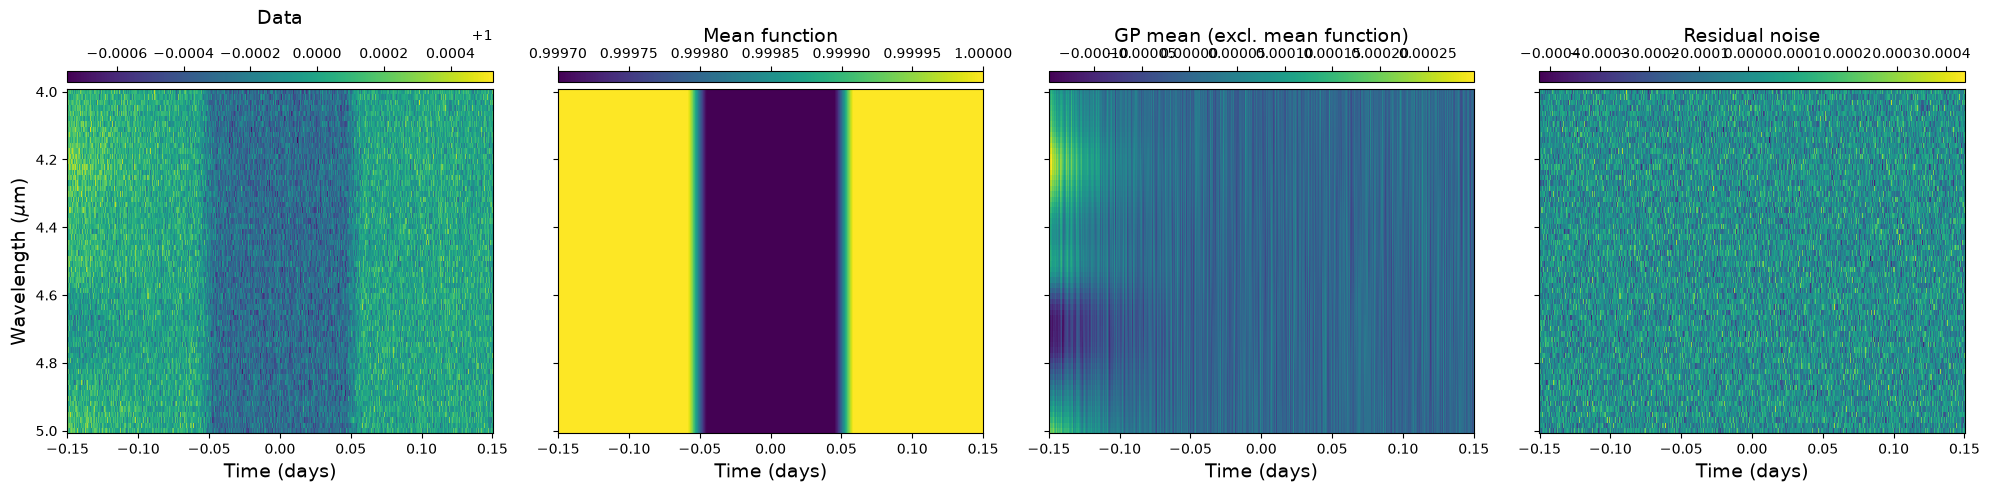

Runtime for log-likelihood calculation with MultiLowRankKernel:
824 μs ± 72.6 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [16]:
def kf_multilowranktime(p, X):
    # Our kernel with measurement covariance from before
    s_l = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.quasisep.Exp(jnp.exp(p["log_l_readout"][0]))
    s_t = luas.kernels.quasisep.KroneckerDelta()

    # Our kernel describing detector settling which has an amplitude which is correlated in wavelength
    k_l1 = jnp.exp(2*p["log_h_ramp"][0]) * luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_l_ramp"][0]))
    settle_vec = jnp.exp(-(X[1] - X[1][0])/jnp.exp(p["log_l_t_ramp"][0]))
    beta_t1 = luas.kernels.lowrank.Amplitude(settle_vec)

    # Warning: Make sure to include the terms s_l, s_t first as they build invertible covariance matrices which luas will use
    # We simply include our new Kronecker product as a second tuple returned
    return (s_l, s_t), (k_l1, beta_t1)

# Feel free to play around with the dataset size to see runtime difference
N_l = 64    # Number of wavelengths
N_t = 1024  # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

hp = {
    "log_sigma":np.log(100e-6)*np.ones(N_l),

    "log_h_readout":np.log(30e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),

    "log_h_ramp":np.log(200e-6)*np.ones(1),
    "log_l_l_ramp":np.log(0.4)*np.ones(1),
    "log_l_t_ramp":np.log(0.03)*np.ones(1),
}
p_init.update(hp)

gp = luas.GP(p_init, X, mf = eclipse_2D, kf = kf_multilowranktime, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# sample from the GP prior again
Y = gp.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"])
plt.show()

print("Runtime for log-likelihood calculation with MultiLowRankKernel:")
%timeit gp.logL(p_init, Y).block_until_ready()

We can actually combine this with a 2D kernel very efficiently, as the ``LuasPlusMultiLowRankKernel`` can maintain quasiseparable matrix decompositions in the longer dimension so long as the low-rank term is in the longer dimension, i.e. kernels like this scale linearly with time:
$$
\begin{equation}
    k(\lambda, \lambda', t, t') = s_\lambda(\lambda, \lambda')s_\mathrm{t; quasi}(t, t') + k_{\lambda}(\lambda, \lambda')k_\mathrm{t; quasi}(t, t') + \sum_{j=1}^{N_\beta}k_{\lambda_j}(\lambda, \lambda')\beta_j(t) \beta_j(t'),\nonumber
\end{equation}
$$
While kernels like this will not be able to exploit quasiseparability at all, even if all the time kernels are quasiseparable:
$$
\begin{equation}
    k(\lambda, \lambda', t, t') = s_\lambda(\lambda, \lambda')s_\mathrm{t}(t, t') + k_{\lambda}(\lambda, \lambda')k_\mathrm{t}(t, t') + \sum_{i=1}^{N_\alpha}\alpha_i(\lambda) \alpha_i(\lambda') k_{t_i}(t, t'),\nonumber
\end{equation}
$$
This is because an eigendecomposition of a time covariance matrix is needed in the latter case and so it will typically have a cubic scaling in time (it could however exploit quasiseparable kernels in wavelength, but this might be negligible if the time dimension is much longer).

Let's combine the detector settling kernel with the 2D correlation term from before, i.e.:

$$
\begin{aligned}
    s_\lambda(\lambda, \lambda') &= \sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right) &\hspace{2em} s_t(t, t') &= \delta_{t t'} \\
    k_\lambda(\lambda, \lambda') &= h^2 \text{Matérn}_{5/2}\left(-\frac{|\lambda - \lambda'|}{l_\lambda}\right) &\hspace{2em} k_{t}(t, t') &= \text{Matérn}_{3/2}\left(-\frac{|t - t'|}{l_{t}}\right)\\
    k_{\lambda_1}(\lambda, \lambda') &= h^2_\textrm{ramp}\text{Matérn-3/2}\left(-\frac{|\lambda - \lambda'|}{l_\mathrm{\lambda_{ramp}}}\right) &\hspace{2em} \mathbf{\beta}_{t, 1} &= \exp\left(-\frac{\mathbf{t} - t_0}{l_\mathrm{t_{ramp}}}\right)
\end{aligned}
$$

Using GP optimisation LuasPlusMultiLowRankKernel


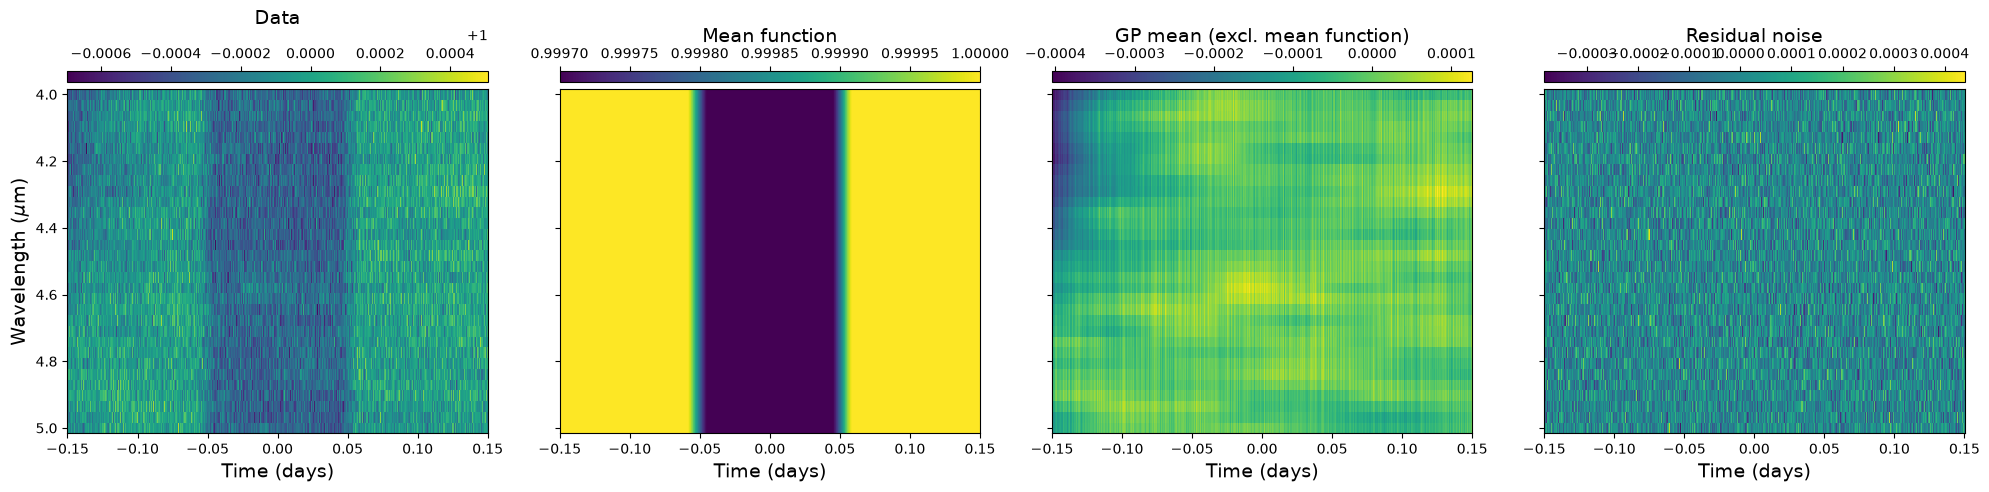

Runtime for log-likelihood calculation with LuasPlusMultiLowRankKernel:
11.1 ms ± 452 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [17]:
def kf_luaspluslowrank(p, X):
    # Our kernel with measurement covariance from before
    s_l = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.quasisep.Exp(jnp.exp(p["log_l_readout"][0]))
    s_t = luas.kernels.quasisep.KroneckerDelta()

    # Our kernel describing 2D correlation in time and wavelength
    # switching the wavelength kernel to be quasiseparable makes no difference here as it must be eigendecomposed
    k_l = jnp.exp(2*p["log_h"][0]) * luas.kernels.Matern52(jnp.exp(p["log_l_l"][0]))

    # This is important to keep quasisep however for good scaling in time
    k_t = luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_t"][0]))


    # Our kernel describing detector settling which has an amplitude which is correlated in wavelength
    k_l1 = jnp.exp(2*p["log_h_ramp"][0]) * luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_l_ramp"][0]))
    settle_vec = jnp.exp(-(X[1] - X[1][0])/jnp.exp(p["log_l_t_ramp"][0]))
    beta_t1 = luas.kernels.lowrank.Amplitude(settle_vec)

    # Warning: Make sure to include the terms s_l, s_t first as they build invertible covariance matrices which luas will use
    # We simply include our new Kronecker product as a second tuple returned
    return (s_l, s_t), (k_l, k_t), (k_l1, beta_t1)


# Feel free to play around with the dataset size to see runtime difference
N_l = 32    # Number of wavelengths
N_t = 1024  # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

hp = {
    "log_sigma":np.log(100e-6)*np.ones(N_l),

    "log_h_readout":np.log(30e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),

    "log_h":np.log(30e-6)*np.ones(1),
    "log_l_l":np.log(0.04)*np.ones(1),
    "log_l_t":np.log(0.04)*np.ones(1),

    "log_h_ramp":np.log(200e-6)*np.ones(1),
    "log_l_l_ramp":np.log(0.4)*np.ones(1),
    "log_l_t_ramp":np.log(0.03)*np.ones(1),
}
p_init.update(hp)

# luas will identify fast, exact optimisations to use on initialisation, but we are free to specify any valid one we wish
# Here we will force it to use LuasKernel, it will otherwise use MultiLowRankKernel which we will explain later
gp = luas.GP(p_init, X, mf = eclipse_2D, kf = kf_luaspluslowrank, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# sample from the GP prior again
Y = gp.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"])
plt.show()

print("Runtime for log-likelihood calculation with LuasPlusMultiLowRankKernel:")
%timeit gp.logL(p_init, Y).block_until_ready()

We can also combine low-rank kernels in both dimensions with the ``DoubleMultiLowRankKernel``, which can also exploit quasiseparable kernels in both dimensions provided we don't have any measurement covariance. So white noise with varying amplitude in time and wavelength is allowed, but correlations such as our readout noise term will mean the code can't exploit quasiseparable optimisations in that dimension (it should still work though). This means we can get linear runtime scaling in both time and wavelength!

Let's combine our previous low-rank terms, accounting for common-mode systematics, systematics in the 10th light curve, and detector settling following an exponential decay at the beginning of the observation. Our kernel function looks like:
$$
\begin{equation}
    k(\lambda, \lambda', t, t') = s_\lambda(\lambda, \lambda') s_t(t, t') + \sum_{i=1}^{N_\alpha}\alpha_i(\lambda) \alpha_i(\lambda') k_{t_i}(t, t') + \sum_{j=1}^{N_\beta}k_{\lambda_j}(\lambda, \lambda')\beta_j(t) \beta_j(t'),
\end{equation}
$$
where we have (written as functions this time):
$$
\begin{aligned}
    s_\lambda(\lambda, \lambda') &= \sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right) &\hspace{2em} s_t(t, t') &= \delta_{t t'} \\
    \mathbf{\alpha}_1(\lambda) &= h_\mathrm{const} &\hspace{2em} k_{t_1}(t, t') &= \text{Matérn}_{3/2}\left(-\frac{|t - t'|}{l_{t_1}}\right)\\
    \mathbf{\alpha}_2(\lambda) &= h_\mathrm{10}\delta_{\lambda\lambda_{10}} &\hspace{2em} k_{t_2}(t, t') &= \exp\left(-\frac{|t - t'|^2}{l_{t_2}^2}\right)\\
    k_{\lambda_1}(\lambda, \lambda') &= h^2_\textrm{ramp}\text{Matérn-3/2}\left(-\frac{|\lambda - \lambda'|}{l_\mathrm{\lambda_{ramp}}}\right) &\hspace{2em} \beta_1(t) &= \exp\left(-\frac{\mathbf{t} - t_0}{l_\mathrm{t_{ramp}}}\right)
\end{aligned}
$$


Using GP optimisation DoubleMultiLowRankKernel


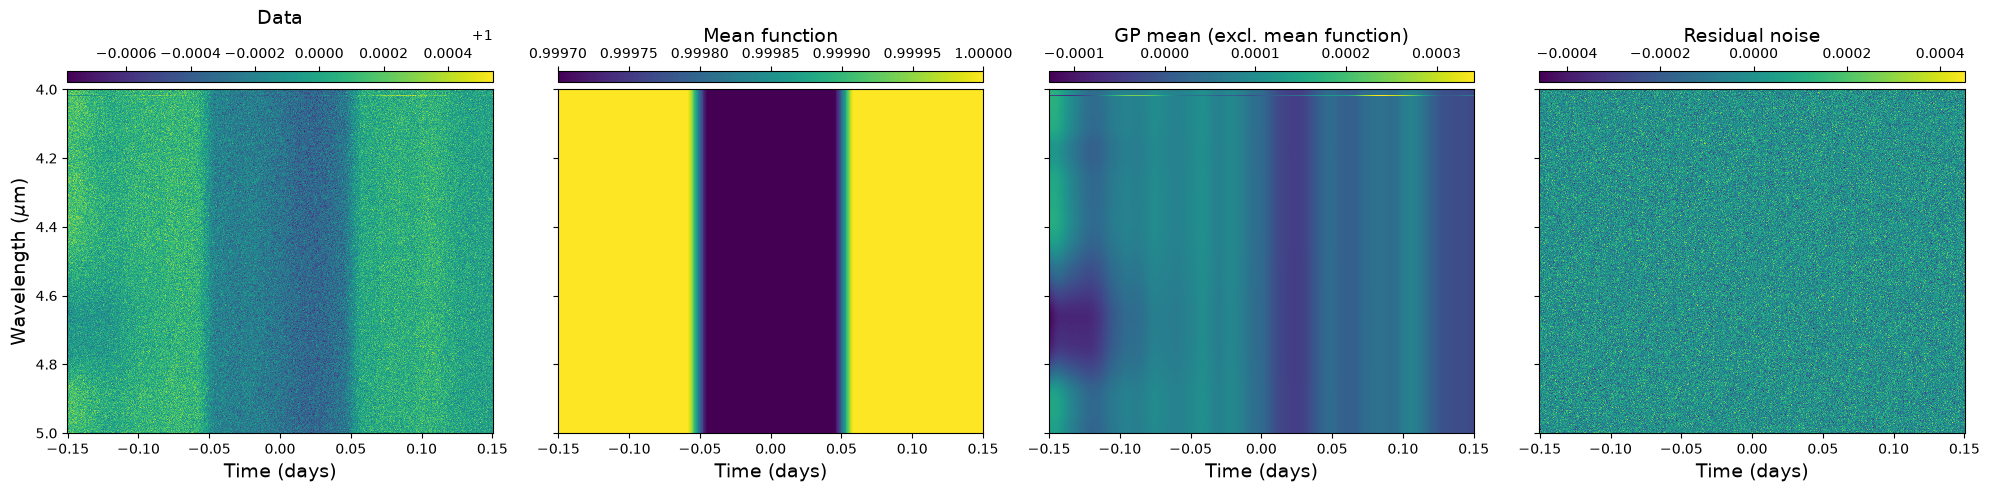

Runtime for log-likelihood calculation with DoubleMultiLowRankKernel:
9.86 ms ± 847 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [18]:
def kf_doublelowrankterms(p, X):
    # Our kernel with measurement covariance from before
    s_l = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"]))

    # Comment out readout noise so quasiseparability can be exploited in wavelength dimension too
    # s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.quasisep.Exp(jnp.exp(p["log_l_readout"][0]))

    s_t = luas.kernels.quasisep.KroneckerDelta()

    # Our kernel describing time-correlated noise which is constant in wavelength
    alpha_l1 = luas.kernels.lowrank.Constant(jnp.exp(p["log_h_const"][0]))
    k_t1 = luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_t1"][0]))

    # Additional time-correlated systematics in the 10th light curve
    e_1 = jnp.zeros(X[0].shape[-1])
    e_1 = jnp.exp(p["log_h10"][0]) * e_1.at[9].set(1.)
    alpha_l2 = luas.kernels.lowrank.Amplitude(e_1)
    k_t2 = luas.kernels.quasisep.SquaredExpApprox(jnp.exp(p["log_l_t2"][0]))

    # Our kernel describing detector settling which has an amplitude which is correlated in wavelength
    k_l1 = jnp.exp(2*p["log_h_ramp"][0]) * luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_l_ramp"][0]))
    settle_vec = jnp.exp(-(X[1] - X[1][0])/jnp.exp(p["log_l_t_ramp"][0]))
    beta_t1 = luas.kernels.lowrank.Amplitude(settle_vec)

    # Warning: Make sure to include the terms s_l, s_t first as they build invertible covariance matrices which luas will use
    # We simply include our new Kronecker product as a second tuple returned
    return (s_l, s_t), (alpha_l1, k_t1), (alpha_l2, k_t2), (k_l1, beta_t1)


# Feel free to play around with the dataset size to see runtime difference
N_l = 512    # Number of wavelengths
N_t = 512  # Number of timepoints

x_l = jnp.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

hp = {
    "log_sigma":np.log(100e-6)*np.ones(N_l),

    # Can include if testing it with readout noise
    # "log_h_readout":np.log(30e-6)*np.ones(1),
    # "log_l_readout":np.log(0.3)*np.ones(1),

    "log_h_const":np.log(80e-6)*np.ones(1),
    "log_l_t1":np.log(0.04)*np.ones(1),

    "log_h10":np.log(100e-6)*np.ones(1),
    "log_l_t2":np.log(0.02)*np.ones(1),

    "log_h_ramp":np.log(200e-6)*np.ones(1),
    "log_l_l_ramp":np.log(0.4)*np.ones(1),
    "log_l_t_ramp":np.log(0.03)*np.ones(1),
}
p_init.update(hp)

# luas will automatically use the DoubleMultiLowRankKernel
gp = luas.GP(p_init, X, kf = kf_doublelowrankterms, mf = eclipse_2D, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# sample from the GP prior again
Y = gp.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"])
plt.show()

print("Runtime for log-likelihood calculation with DoubleMultiLowRankKernel:")
%timeit gp.logL(p_init, Y).block_until_ready()

Now to show the full flexibility of ``luas``, we'll put all these previous kernel terms together. The ``ExtendedLuasKernel`` doesn't scale amazingly well, scaling as ~$\mathcal{O}((1+N_\alpha^3) N_t^3 + (1+N_\beta^3) N_\lambda^3)$ in runtime, but for a small enough dataset it gives a very high level of flexibility at a doable speed. It should also run much faster on a GPU if you have that available. The full kernel function here is:
$$
\begin{equation}
    k(\lambda, \lambda', t, t') = s_\lambda(\lambda, \lambda') s_t(t, t') + k_{\lambda}(\lambda, \lambda')k_{t}(t, t') + \sum_{i=1}^{N_\alpha}\alpha_i(\lambda) \alpha_i(\lambda') k_{t_i}(t, t') + \sum_{j=1}^{N_\beta}k_{\lambda_j}(\lambda, \lambda')\beta_j(t) \beta_j(t'),
\end{equation}
$$
where we have (written as functions):
$$
\begin{aligned}
    s_\lambda(\lambda, \lambda') &= \sigma^2(\lambda)\delta_{\lambda\lambda'} + h^2_\textrm{readout}\exp\left(-\frac{|\lambda - \lambda'|}{l_\textrm{readout}}\right) &\hspace{2em} s_t(t, t') &= \delta_{t t'} \\
    k_\lambda(\lambda, \lambda') &= h_\lambda(\lambda)h_\lambda(\lambda') \text{Matérn}_{5/2}\left(-\frac{|\lambda - \lambda'|}{l_\lambda}\right) &\hspace{2em} k_{t}(t, t') &= \text{Matérn}_{3/2}\left(-\frac{|t - t'|}{l_{t}}\right)\\
    \mathbf{\alpha}_1(\lambda) &= h_\mathrm{const} &\hspace{2em} k_{t_1}(t, t') &= \text{Matérn}_{3/2}\left(-\frac{|t - t'|}{l_{t_1}}\right)\\
    \mathbf{\alpha}_2(\lambda) &= h_\mathrm{10}\delta_{\lambda\lambda_{10}} &\hspace{2em} k_{t_2}(t, t') &= \exp\left(-\frac{|t - t'|^2}{l_{t_2}^2}\right)\\
    k_{\lambda_1}(\lambda, \lambda') &= h^2_\textrm{ramp}\text{Matérn-3/2}\left(-\frac{|\lambda - \lambda'|}{l_\mathrm{\lambda_{ramp}}}\right) &\hspace{2em} \beta_1(t) &= \exp\left(-\frac{\mathbf{t} - t_0}{l_\mathrm{t_{ramp}}}\right)
\end{aligned}
$$
This kernel can't exploit quasiseparability, so we will switch the `luas.kernels.quasisep.SquaredExpApprox` kernel back to the exact `luas.kernels.SquaredExp` kernel, but there's no harm in keeping the `luas.kernels.quasisep` kernels for the other terms, they just aren't likely to run any faster than the base kernels in `luas.kernels`

Using GP optimisation ExtendedLuasKernel


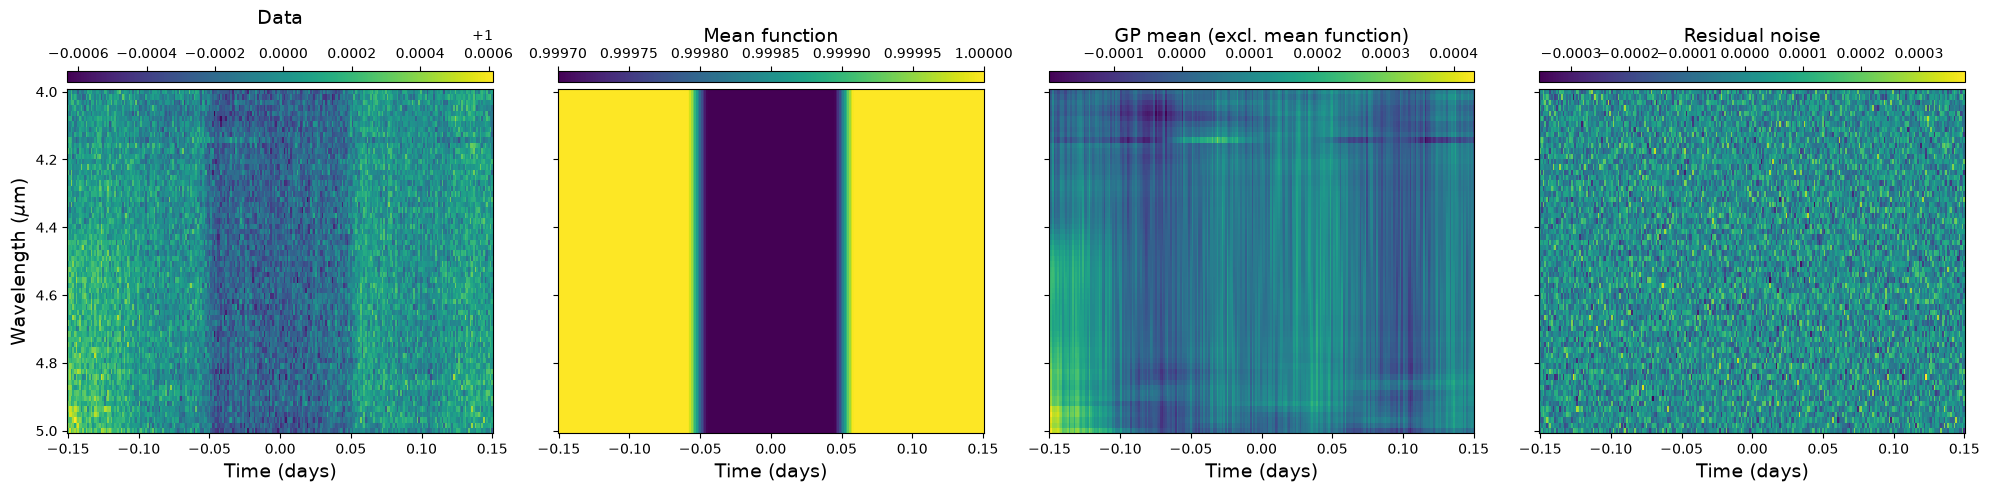

Runtime for log-likelihood calculation with Extended Luas Kernel:
16.2 ms ± 811 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [19]:
def kf_extendedluas(p, X):
    # Our kernel with measurement covariance from before
    s_l = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.quasisep.Exp(jnp.exp(p["log_l_readout"][0]))
    s_t = luas.kernels.quasisep.KroneckerDelta()

    # Our kernel describing time-correlated noise which is constant in wavelength
    k_l = luas.kernels.lowrank.Amplitude(jnp.exp(p["log_h_l_vec"])) * luas.kernels.Matern52(jnp.exp(p["log_l_l"][0]))
    k_t = luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_t"][0]))

    # Our kernel describing time-correlated noise which is constant in wavelength
    alpha_l1 = luas.kernels.lowrank.Constant(jnp.exp(p["log_h_const"][0]))
    k_t1 = luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_t1"][0]))

    e_1 = jnp.zeros(X[0].shape[-1])
    e_1 = jnp.exp(p["log_h10"][0]) * e_1.at[9].set(1.)
    alpha_l2 = luas.kernels.lowrank.Amplitude(e_1)
    # Can't exploit quasisep kernels for this optimisation, so no point of approximate squared exp kernel
    k_t2 = luas.kernels.SquaredExp(jnp.exp(p["log_l_t2"][0]))

    # Our kernel describing detector settling which has an amplitude which is correlated in wavelength
    k_l1 = jnp.exp(2*p["log_h_ramp"][0]) * luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_l_ramp"][0]))
    settle_vec = jnp.exp(-(X[1] - X[1][0])/jnp.exp(p["log_l_t_ramp"][0]))
    beta_t1 = luas.kernels.lowrank.Amplitude(settle_vec)

    # Warning: Make sure to include the terms s_l, s_t first as they build invertible covariance matrices which luas will use
    # We simply include our new Kronecker product as a second tuple returned
    return (s_l, s_t), (k_l, k_t), (alpha_l1, k_t1), (alpha_l2, k_t2), (k_l1, beta_t1)


# Feel free to play around with the dataset size to see runtime difference
N_l = 64    # Number of wavelengths
N_t = 256  # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

h_l_vec = 200e-6 * (X[0] - X[0].mean())**2 * np.ones(N_l)

hp = {
    "log_sigma":np.log(100e-6)*np.ones(N_l),

    "log_h_readout":np.log(40e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),

    "log_h_l_vec":np.log(h_l_vec)*np.ones(1),
    "log_l_l":np.log(0.02)*np.ones(1),
    "log_l_t":np.log(0.04)*np.ones(1),

    "log_h_const":np.log(80e-6)*np.ones(1),
    "log_l_t1":np.log(0.04)*np.ones(1),

    "log_h10":np.log(100e-6)*np.ones(1),
    "log_l_t2":np.log(0.02)*np.ones(1),

    "log_h_ramp":np.log(200e-6)*np.ones(1),
    "log_l_l_ramp":np.log(0.4)*np.ones(1),
    "log_l_t_ramp":np.log(0.03)*np.ones(1),
}
p_init.update(hp)

# luas will automatically use the ExtendedLuasKernel
gp = luas.GP(p_init, X, mf = eclipse_2D, kf = kf_extendedluas, logPrior = logPrior)

# Ensure a consistent noise draw
np.random.seed(42)

# sample from the GP prior again
Y = gp.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"])
plt.show()

print("Runtime for log-likelihood calculation with Extended Luas Kernel:")
%timeit gp.logL(p_init, Y).block_until_ready()

We can once again plot this covariance matrix in terms of all its component covariance matrices

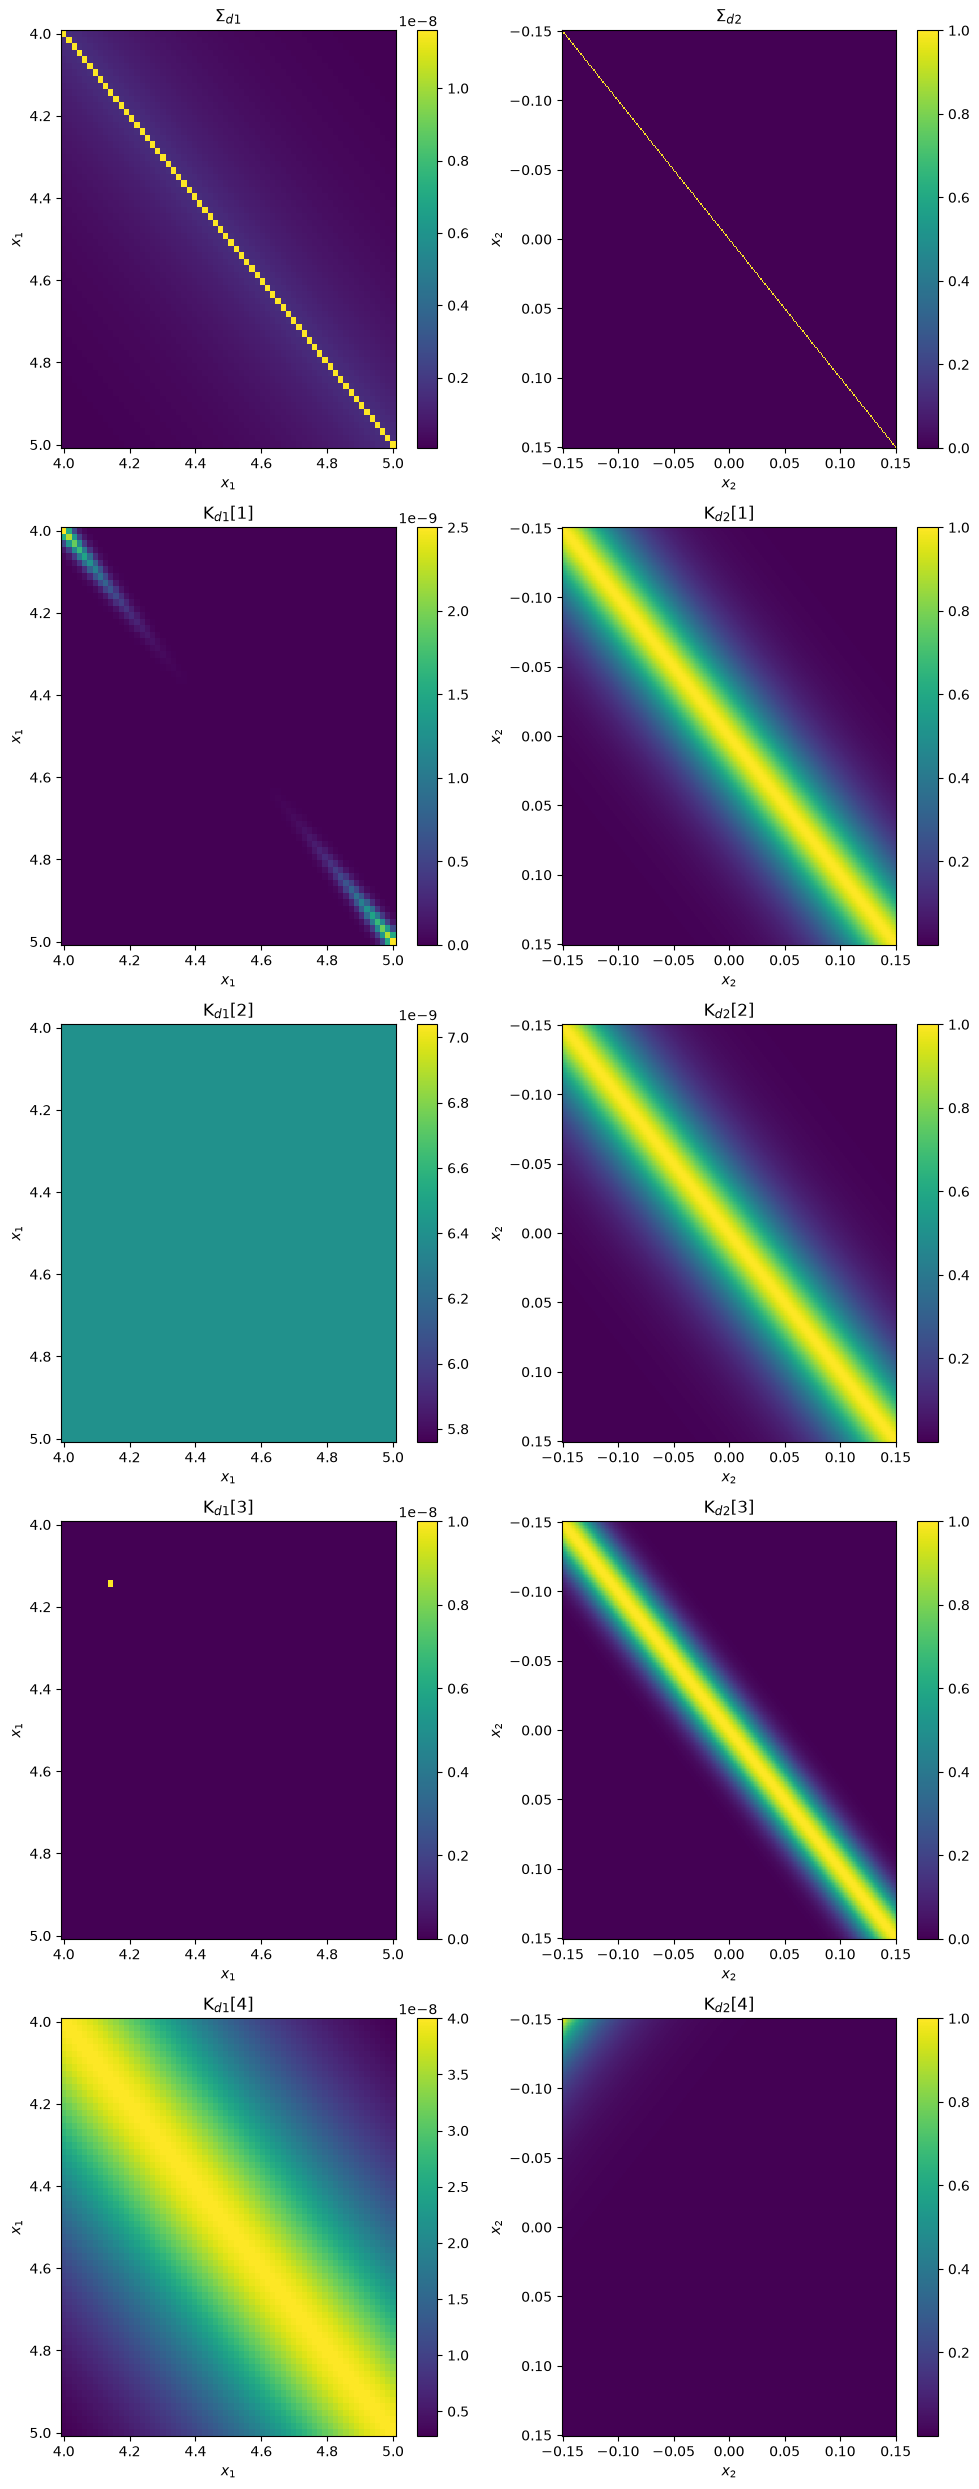

In [20]:
gp.plot_cov_mat(p_init)

Now let's do some optimising and MCMC analysis. We'll just use our super optimised measurement covariance plus common-mode systematics model from earlier, but feel free to play around with various kernel functions (hopefully they're gradients are all numerically stable... still a bit of a work in progress).

Using GP optimisation LuasLasrachKernel/MultiLowRankKernel


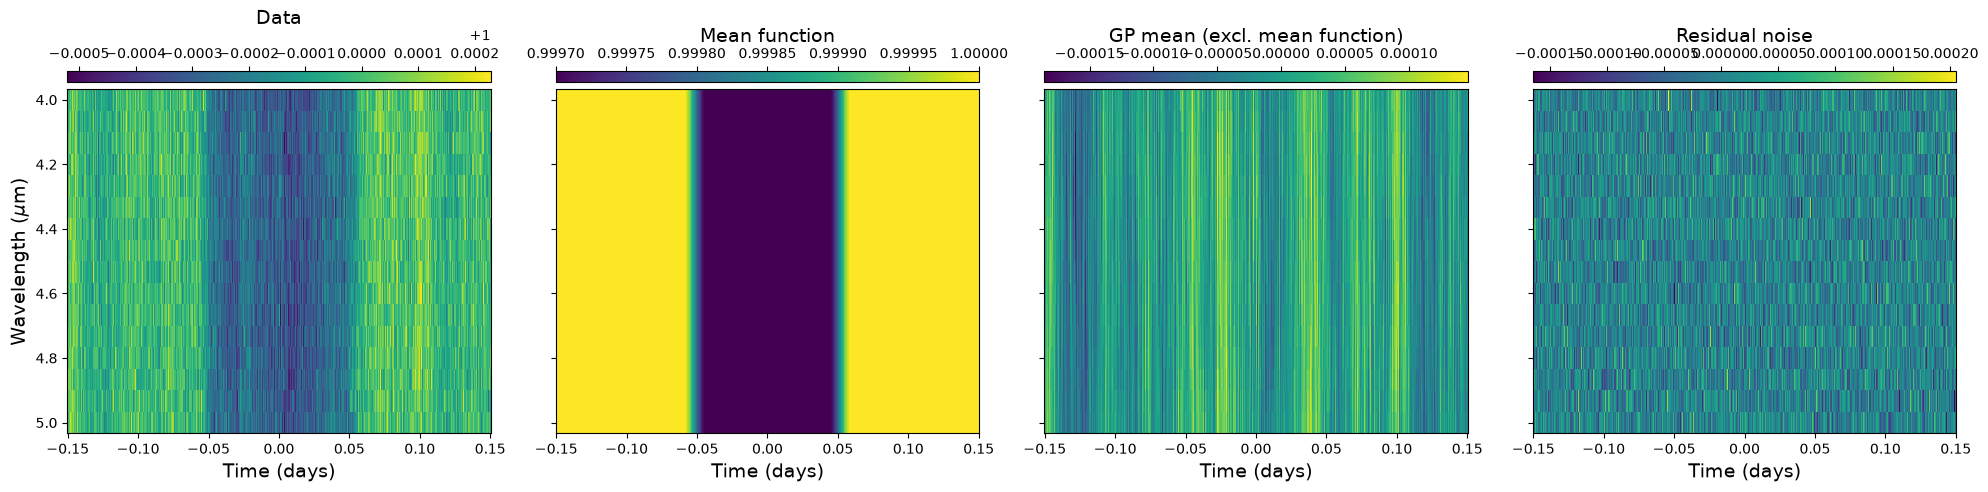

Starting log posterior value: 67889.45670999837


In [61]:
def kf(p, X):
    # Our kernel with measurement covariance from before
    s_l = luas.kernels.quasisep.Noise(jnp.exp(p["log_sigma"]))
    s_l += jnp.exp(2*p["log_h_readout"][0]) * luas.kernels.quasisep.Exp(jnp.exp(p["log_l_readout"][0]))
    s_t = luas.kernels.quasisep.KroneckerDelta()

    # Our kernel describing time-correlated noise which is constant in wavelength
    k_l = luas.kernels.lowrank.Constant(jnp.exp(p["log_h"][0]))
    k_t = luas.kernels.quasisep.Matern32(jnp.exp(p["log_l_t"][0]))

    # Warning: Make sure to include the terms s_l, s_t first as they build invertible covariance matrices which luas will use
    # We simply include our new Kronecker product as a second tuple returned
    return (s_l, s_t), (k_l, k_t)


# Feel free to play around with the dataset size to see runtime difference
N_l = 16    # Number of wavelengths
N_t = 512   # Number of timepoints

x_l = np.linspace(4., 5., N_l)
x_t = jnp.linspace(-0.15, 0.15, N_t)
X = (x_l, x_t)

p_init = deepcopy(mfp)
p_init["fp_fs"] = 300e-6*np.ones(N_l)
p_init["Foot"] = 1.*np.ones(N_l)
p_init["Tgrad"] = 0.*np.ones(N_l)

hp = {
    "log_sigma":np.log(50e-6)*np.ones(N_l),

    "log_h_readout":np.log(40e-6)*np.ones(1),
    "log_l_readout":np.log(0.3)*np.ones(1),

    "log_h":np.log(40e-6)*np.ones(1),
    "log_l_t":np.log(0.01)*np.ones(1),
}
p_init.update(hp)

# This should default to luas.LuasLasrachKernel if use_kernel is not specified
gp = luas.GP(p_init, X, kf = kf, mf = eclipse_2D, logPrior = logPrior, verbose = True)

# Ensure a consistent noise draw
np.random.seed(42)

# sample from the GP prior again
Y = gp.sample(p_init, add_mf = True)

# Visualise the simulated data and the initial GP fit to the data (in this case the GP fit has the optimal simulated parameters)
gp.plot(p_init, Y, axes_labels = [r"Wavelength ($\mu$m)", r"Time (days)"])
plt.show()

print("Starting log posterior value:", gp.logP(p_init, Y))

For the optimisation, we will use the `optimise` convenience method of a ``luas.GP`` object, which automatically builds a PyMC object which either takes a parameter to have a flat uniform prior within it's parameterisation given, or else uniform bounds specified here with an input ``param_bounds`` PyTree. Make sure each parameter name in ``param_bounds`` maps to a list of the form (lower_bound, upper_bound), with both bounds in the same shape as the parameters. The optimiser will use the GP ``logP`` method so any additional priors can be specified when initialising the GP object using the ``logPrior`` function.

We will later add how to build a PyMC model yourself in case you want more flexibility or transparance with how this is done

In [ ]:
# Let's define some bounds
min_log_l_t = np.log(np.diff(x_t).min())
max_log_l_t = np.log(0.25*(x_t[-1] - x_t[0]))

# Note with PyMC that the parameter bounds must also be NumPy arrays
param_bounds = {
                # Can optionally include bounds on some parameters
                # but often they will be well constrained by the data
                "T0":[np.array([-0.02]), np.array([0.02])],
                "rho":[np.array([0.]), np.array([1.])],

                # Sometimes prior bounds on hyperparameters are important for sampling
                # However their choice can sometimes affect the results so use with caution
                "log_h":   [np.log(1e-6)*np.ones(1), np.log(1)*np.ones(1)],
                "log_h_readout": [np.log(1e-6)*np.ones(1), np.log(1)*np.ones(1)],
                "log_l_t": [min_log_l_t*np.ones(1), max_log_l_t*np.ones(1)],
                "log_sigma":[np.log(1e-6)*np.ones(N_l), np.log(1e-2)*np.ones(N_l)],
}

# Example: optimise only parameter names specified in vars
# vars = ["fp_fs"]
# p_opt = gp.optimise(p_init, Y, param_bounds = param_bounds, vars = vars)

# Alternatively, optimise all parameters except those specified in fixed_vars
fixed_vars = ["P"]
p_opt = gp.optimise(p_init, Y, param_bounds = param_bounds, fixed_vars = fixed_vars)

print("Starting log posterior value:", gp.logP(p_init, Y))
print("New optimised log posterior value:", gp.logP(p_opt, Y))

gp.plot(p_opt, Y)

For MCMC tuning with large numbers of parameters, it can be very helpful to use the Laplace approximation to select a good choice of tuning matrix or "mass matrix" for No U-Turn Sampling (NUTS). This can often return quite accurate approximations of the covariance matrix of the posterior - especially when most of the parameters are well constrained. First, let's set return_array = False so that it returns a nested ``PyTree``, so that we can see what our covariance matrices of each parameter looks like from the Laplace approximation.

In [63]:
from luas.jax_convenience_fns import get_corr_mat

# Returns the covariance matrix returned by the Laplace approximation
# Also returns a list of parameters which is the order the array is in
# This matches the way jax.flatten_util.ravel_pytree will sort the parameter PyTree into
cov_mat_pytree, ordered_param_list = gp.laplace_approx(
    p_opt,                  # Make sure to use best-fit values
    Y,                      # The observations being fit
    fixed_vars = fixed_vars,# Make sure to specify fixed parameters as otherwise they are marginalised over
    return_array = False,   # May optionally return a nested PyTree if set to False which can be more readable
    regularise = False,      # Often necessary to regularise values that return negative covariance
    large = True,           # Setting this to True is more memory efficient which may be needed for large data sets
    large_block_size = 64,  # if large=True: Number of columns in each batch the Hessian is broken into, smaller numbers are more memory efficient
)

100%|██████████| 2/2 [00:05<00:00,  2.82s/it]


Visualise the Laplace approximated posterior. While not exact, especially if there are many non-linear parameters and poorly constrained GP hyperparameters, it can often give quite accurate approximations of the true posterior, and doesn't come with the MCMC error from not running a large enough number of samples.

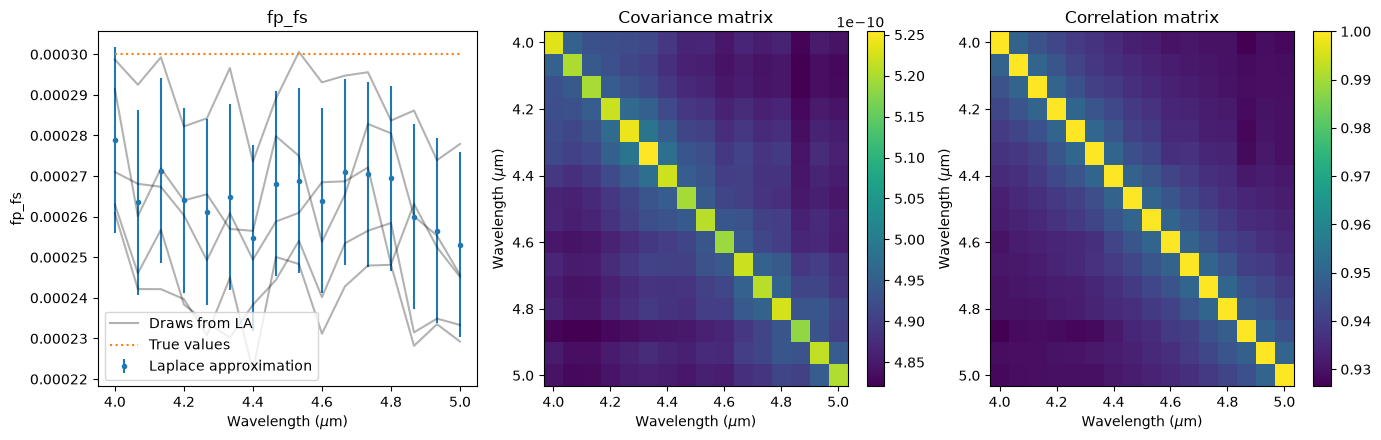

In [64]:
def plot_posterior(x, p_mean, p_cov, p_true = None, axis_name = r"Wavelength ($\mu$m)"):

    p_std = jnp.sqrt(jnp.diag(p_cov))

    cov_draws = np.random.multivariate_normal(p_mean, p_cov, size = 5).T

    fig, ax = plt.subplots(1, 3, figsize = (14, 4.5))
    ax[0].errorbar(x, p_mean, yerr = p_std, fmt = '.', label = "Laplace approximation")
    ax[0].plot(x, cov_draws[:, 0], color = 'k', alpha = 0.3, label = "Draws from LA")
    ax[0].plot(x, cov_draws[:, 1:], color = 'k', alpha = 0.3)

    if p_true is not None:
        ax[0].plot(x, p_true, linestyle = "dotted", label = "True values")

    ax[0].set_title(rf"{param_name}")
    ax[0].set_ylabel(param_name)
    ax[0].set_xlabel(axis_name)
    ax[0].legend()

    ax[1].set_title(r"Covariance matrix")
    im1 = ax[1].pcolormesh(x, x, p_cov)
    ax[1].invert_yaxis()
    plt.colorbar(im1, ax = ax[1])
    ax[1].set_xlabel(axis_name)
    ax[1].set_ylabel(axis_name)

    corr_mat = get_corr_mat(p_cov)
    ax[2].set_title(r"Correlation matrix")
    im1 = ax[2].pcolormesh(x, x, corr_mat)
    ax[2].invert_yaxis()
    plt.colorbar(im1, ax = ax[2])
    plt.tight_layout()
    ax[2].set_ylabel(axis_name)
    ax[2].set_xlabel(axis_name)
    plt.show()

param_name = "fp_fs"
fp_fs_LA_cov = cov_mat_pytree[param_name][param_name]

plot_posterior(x_l, p_opt[param_name], fp_fs_LA_cov, p_true = p_init[param_name])

For the actual tuning matrix for NUTs we will set ``return_array = True``, as this is easier for setting within PyMC. We will also use the ``gp.laplace_approx_with_bounds`` method (and specify our param_bounds as the third parameter) instead of using ``gp.laplace_approx``, because the bounds on our parameters will cause ``PyMC`` to perform a transformation on them which we would like our Laplace approximation to take account of (since they are being sampled within the transformed space). See the ``gp.laplace_approx_with_bounds`` documentation for more details.

In [65]:
# Returns the covariance matrix returned by the Laplace approximation
# within the transformed latent space used by PyMC
# Also returns a list of parameters which is the order the array is in
# This matches the way jax.flatten_util.ravel_pytree will sort the parameter PyTree into
cov_mat, ordered_param_list = gp.laplace_approx_with_bounds(
    p_opt,               # Make sure to use best-fit values
    Y,             # The observations being fit
    param_bounds,        # Specify the same bounds that will be used for the MCMC
    fixed_vars = fixed_vars,  # Make sure to specify fixed parameters as otherwise they are marginalised over
    return_array = True, # May optionally return a nested PyTree if set to False which can be more readable
    regularise = True,   # Often necessary to regularise values that return negative covariance
    large = True,       # Setting this to True is more memory efficient which may be needed for large data sets
    large_block_size = 64,
)

100%|██████████| 2/2 [00:05<00:00,  2.55s/it]


Now here is an example MCMC setup, building a PyMC model with the ``pymc_model`` method of a ``luas.GP`` object, and specifying some parameters in fit for, being careful to ensure our parameters are specified in the same orer as our Laplace approximation tuning matrix. We can also slice sample some parameters, which can be useful for parameters close to bounds, or with unstable or undefined gradients, as slice sampling can be quite robust.

In general, I would strongly recommend beginning with a very simple MCMC where only one or a few mean function parameters are being varied, and vary more parameters together from there. This is because NUTS and most MCMC methods can be highly sensitive to correct tuning and can run extremely slowly if a parameter is poorly tuned or incorrectly defined. Being able to single out which parameters are causing sampling issues can help significantly with bug fixing and picking whether another sampler like slice sampling should be used instead.

In [66]:
# Re-initialise our PyMC model with optimised parameters
pymc_model, var_dict, p_pymc = gp.pymc_model(p_opt, Y, param_bounds = param_bounds, fixed_vars = fixed_vars)

# The NUTS step takes as input the variables created when initialising the model
# We also sort these variables in the same order our Laplace approximated covariance matrix is in
# By default this just NUTS samples all non-fixed parameters using the Laplace approximation for the mass matrix
NUTS_fixed_vars = deepcopy(fixed_vars)
NUTS_model_vars = [var_dict[par] for par in ordered_param_list if par not in NUTS_fixed_vars]
steps = [pm.NUTS(NUTS_model_vars, model = pymc_model, scaling = cov_mat, is_cov = True)]

# If you want to add any additional Gibbs sampling steps with different samplers it can help
# in situations like when NUTS sometimes gets stuck at parameter bounds

# slice sampling can be useful for these scenarios and also works when gradients are unstable
# but it performs poorly when parameters share strong correlations with each other
slice_vars = ["log_h", "log_l_t"]
for par in slice_vars:
    steps.append(pm.Slice(var_dict[par], model = pymc_model))

# If you want to NUTS sample parameters without the Laplace approximation
non_LA_NUTS_vars = []
for par in non_LA_NUTS_vars:
    non_LA_NUTS_model_vars = [var_dict[par] for par in non_LA_NUTS_vars]
    steps.append(pm.NUTS(non_LA_NUTS_model_vars, model = pymc_model))

# Begin MCMC sampling, here just with a few samples to get started
# For a real analysis, probably want at least 4 chains and >=4000 total posterior draws
idata = pm.sample(
    model = pymc_model, # PyMC model to sample
    step = steps,       # Sampling steps to use (can be list for blocked Gibbs sampling)
    initvals = p_pymc,  # Starting point of inference (will jitter around this location)
    draws = 1000,       # Number of samples from MCMC post warm-up
    tune = 1000,        # Number of tuning steps
    chains = 2,         # Number of chains to run
    cores = 1,          # This will probably fail if not set to 1 as I don't think PyMC can parallelise JAX functions
)

# Saves the inference object
#idata.to_json(save_location);

Varying parameters: ['Foot', 'T0', 'Tgrad', 'a', 'b', 'fp_fs', 'log_h', 'log_h_readout', 'log_l_readout', 'log_l_t', 'log_sigma', 'rho']
Fixed parameters: ['P']


Sequential sampling (2 chains in 1 job)
CompoundStep
>NUTS: [Foot, T0, Tgrad, a, b, fp_fs, log_h, log_h_readout, log_l_readout, log_l_t, log_sigma, rho]
>Slice: [log_h]
>Slice: [log_l_t]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1269 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


The ``arviz.plot_trace`` function can be very useful for visualising the marginal posterior distributions of the different parameters as well as to examine the chains and diagnose any possible convergence issues, for example:
-If parameters are getting stuck at bounds then adding a slice sampling step can be useful (and potentially removing them from the NUTS step, but doing both is okay)
-If some parameters have complex correlations together then it may help to NUTS sample without a Laplace approximation, where it learns the mass matrix in tuning

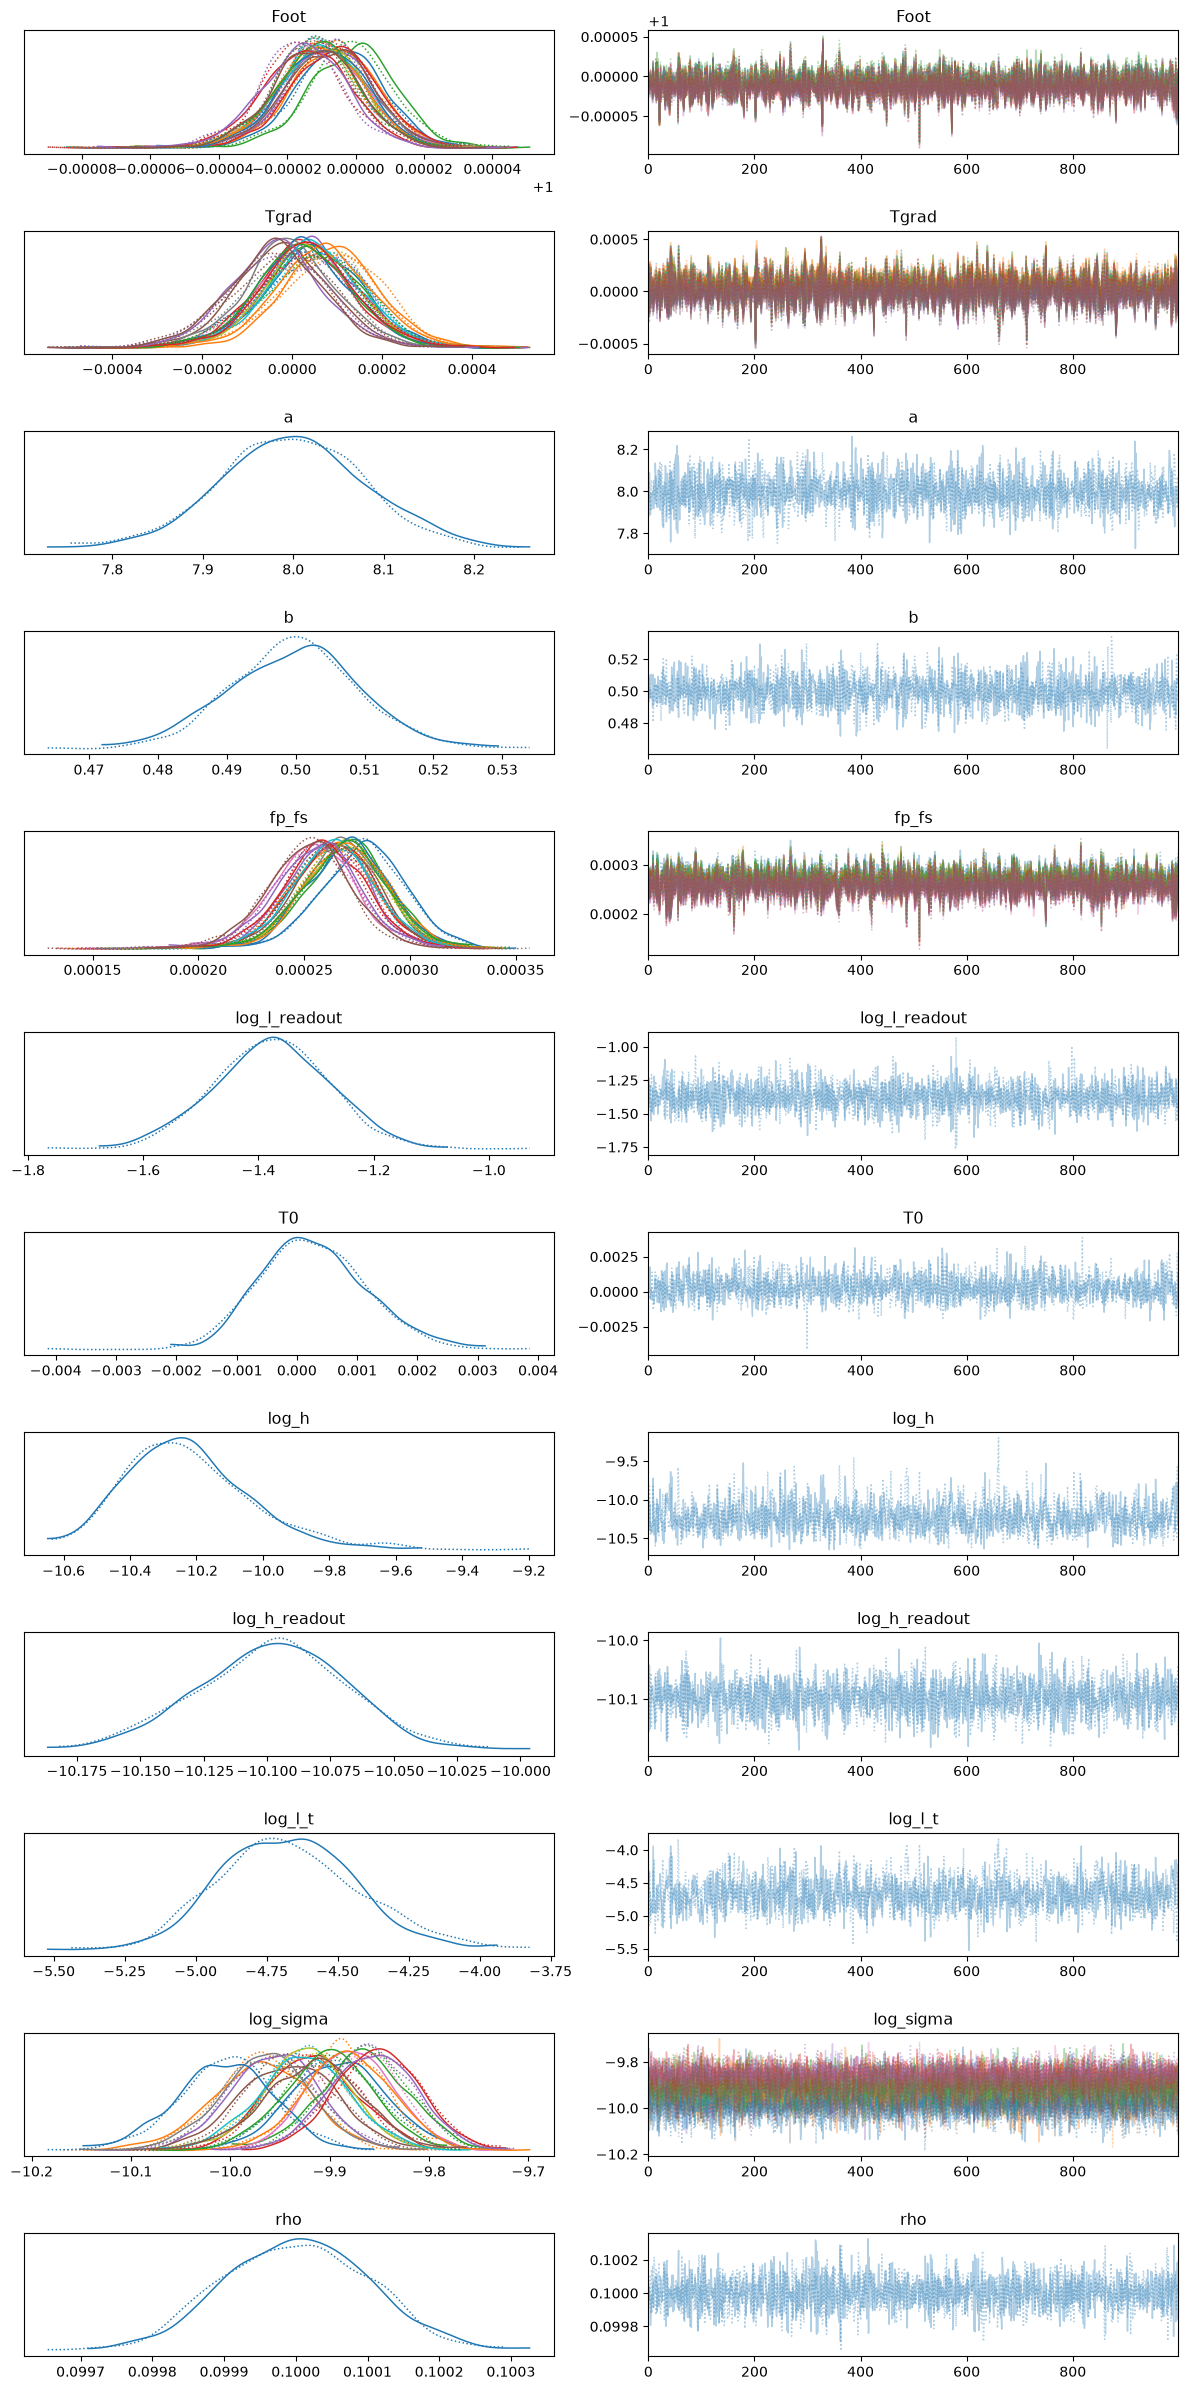

In [72]:
import arviz as az

trace_plot = az.plot_trace(idata)
plt.tight_layout()

Print a summary of the samples using ``arviz``. Important values to look at for convergence are that the effective sample size of the bulk of the distribution (``ess_bulk``) and the tail of the distribution (``ess_tail``) are at least ~500-1000 and that the Gelman-Rubin ``r_hat`` statistic is less than ~1.01 for each parameter.

In [73]:
az.summary(idata, round_to = 6)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Foot[0],0.999995,0.000013,0.999970,1.000019,0.000000,0.000000,2416.955082,1354.750645,0.999397
Foot[1],0.999993,0.000013,0.999969,1.000017,0.000000,0.000000,2376.185586,1529.561574,0.999497
Foot[2],0.999999,0.000013,0.999973,1.000022,0.000000,0.000000,2504.044629,1481.889424,0.999505
Foot[3],0.999993,0.000013,0.999968,1.000016,0.000000,0.000000,2344.109462,1486.526646,0.999665
Foot[4],0.999992,0.000013,0.999967,1.000016,0.000000,0.000000,2429.184539,1483.262789,0.999571
Foot[5],0.999992,0.000013,0.999966,1.000016,0.000000,0.000000,2519.681194,1468.120829,1.000407
Foot[6],0.999990,0.000013,0.999963,1.000012,0.000000,0.000000,2609.852697,1436.781373,0.999791
Foot[7],0.999990,0.000013,0.999966,1.000014,0.000000,0.000000,2612.112009,1340.188184,0.999873
Foot[8],0.999989,0.000013,0.999964,1.000013,0.000000,0.000000,2470.342622,1290.793037,1.000734
Foot[9],0.999989,0.000013,0.999966,1.000015,0.000000,0.000000,2458.134754,1485.476018,0.999603


``corner`` is great for generating nice corner plots. Unfortunately when fitting many light curves the number of parameters can make visualising the full corner plot quite unwieldly but we can always just plot subsets of parameters instead.

In [ ]:
from corner import corner

# Select the parameters to include in the plot
params = ["T0", "a", "b", "log_h", "log_l_t", "log_h_readout", "log_l_readout", "fp_fs"]

# Plot each of the two chains separately
idata_corner1 = idata.sel(chain=[0])
idata_corner2 = idata.sel(chain=[1])

# Plot first chain
fig1 = corner(idata_corner1, smooth = 0.4, var_names = params)

# Plot second chain along with truth values
fig2 = corner(idata_corner2, quantiles=[0.16, 0.5, 0.84], title_fmt = None, title_kwargs={"fontsize": 23},
              label_kwargs={"fontsize": 23}, show_titles=True, smooth = 0.4, color = "r", fig = fig1,
              top_ticks = True, max_n_ticks = 2, labelpad = 0.16, var_names = params,
              truths = p_init, truth_color = "k",
              )

If you want to examine the chains for any parameters you can use ``idata.posterior[param]`` to get an ``xarray.DataArray`` object and can use the ``to_numpy`` method to convert to a ``NumPy`` array. Below we retrieve the mean and covariance matrix of the radius ratio parameters and then visualise the emission spectrum as well as the covariance matrix of the emission spectrum.

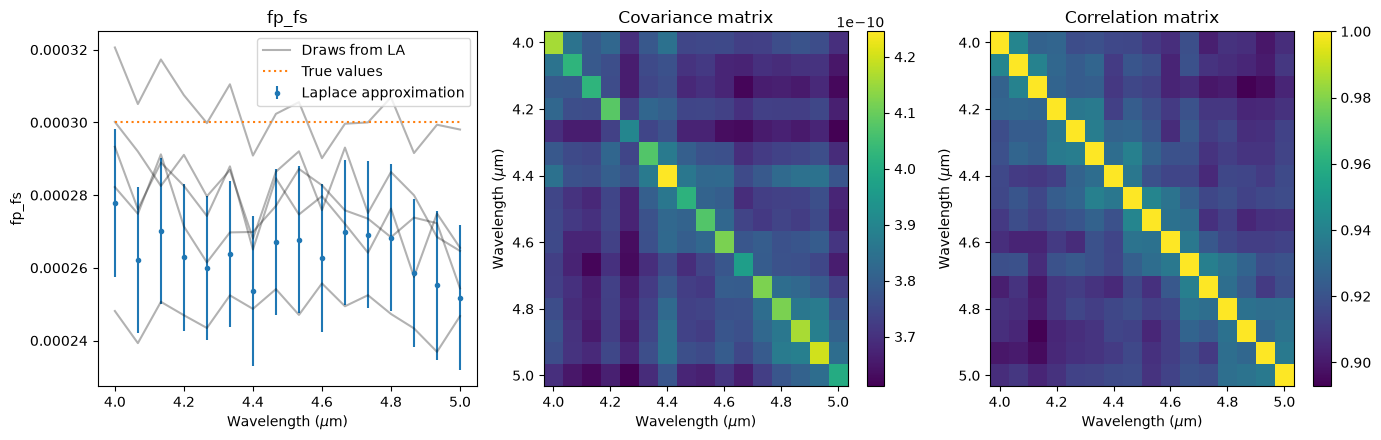

In [70]:
from luas.jax_convenience_fns import get_corr_mat

# NumPy array of MCMC samples of shape (N_chains, N_draws, N_l)
param_name = "fp_fs"
param_chains = idata.posterior[param_name].to_numpy()

# Get the mean radius ratio values averaged over all chains and draws
param_mean = param_chains.mean((0, 1))

# Calculate the covariance matrix of each chain and average together
N_chains = param_chains.shape[0]
param_cov = jnp.zeros((N_l, N_l))
for i in range(N_chains):
    param_cov += jnp.cov(param_chains[0, :, :].T)
param_cov /= N_chains

# We can plot our recovered spectrum against the simulated true spectrum
# The covariance from the chains will be noisy without at least a few thousand samples
plot_posterior(x_l, param_mean, param_cov, p_true = p_init[param_name])

It can be hard to tell when there are significant correlations involved whether the recovered spectrum is actually consistent with the simulated spectrum. The reduced chi-squared statistic $\chi_r^2$ is useful for determining this. It is calculated using:

$$
\begin{equation}
    \chi_\mathrm{r}^2 = (\bar{\vec{\rho}}_\mathrm{ret} - \vec{\rho}_\mathrm{inj})^T \mathbf{K}_\mathrm{\vec{\rho}; ret}^{-1} (\bar{\vec{\rho}}_\mathrm{ret} - \vec{\rho}_\mathrm{inj}) / N_l,
\end{equation}
$$

Where $\bar{\vec{\rho}}_\mathrm{ret}$ is our retrieved mean emission spectrum, $\vec{\rho}_\mathrm{inj}$ is the injected emission spectrum and $\mathbf{K}_\mathrm{\vec{\rho}; ret}$ is our retrieved covariance matrix of the emission spectrum.

In [75]:
r = param_mean - p_init[param_name]
chi2_r = r.T @ jnp.linalg.inv(param_cov) @ r / N_l

print("Reduced chi-squared value:", chi2_r)

# The reduced chi-squared distribution always has mean 1 but has different standard deviations
# depending on the numbers of degrees of freedom
print("Distribution of reduced chi-squared: mean = 1, std. dev. =", jnp.sqrt(2/N_l))

Reduced chi-squared value: 1.5263486739835341
Distribution of reduced chi-squared: mean = 1, std. dev. = 0.3535533905932738
